# Speed–Unit Correlation Analysis

For every **good** and **MUA** unit we compute the Pearson correlation between the
unit's continuous firing rate and the mouse's movement speed over the full session.

Pipeline:
1. Load session data (same as `direct_path_analysis.ipynb`).
2. Compute a session-wide speed trace from `summary_df` coordinate tracking.
3. For each unit, build a continuous firing-rate trace (Gaussian-smoothed spike histogram).
4. Compute Pearson r; plot the distribution to choose a threshold.
5. For units above threshold: plot speed + firing rate over a random session window.
6. For units above threshold: find and plot the best-correlated time segments via rolling correlation.

In [1]:
import scipy.io
import pandas as pd
import numpy as np
import pickle
import random
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# Import speed_analysis directly from its file path — this avoids going through
# navigraph/analysis/__init__.py, which triggers navigraph/core/__init__.py →
# experiment_runner → omegaconf (not installed in this environment).
import importlib.util as _ilu
_sa_path = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/navigraph/analysis/speed_analysis.py')
_spec = _ilu.spec_from_file_location('speed_analysis', _sa_path)
_mod  = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
compute_path_speed = _mod.compute_path_speed

In [2]:
FPS  = 40        # video frame rate (Hz)
FS   = 30_000    # Neuropixels sampling rate (Hz)
MAZE_START = 30
MAZE_END   = 767

# Firing-rate smoothing kernel width (seconds)
RATE_SMOOTH_SIGMA_S = 0.5

# Speed smoothing (frames) — same default as speed_analysis.py
SPEED_SMOOTH_FRAMES = 5

## Session setup

In [3]:
session = '10/09/2025'

YY   = session[-2:]
YYYY = session[-4:]
MM   = session[3:5]
DD   = session[:2]

DD_MM_YYYY = f"{DD}_{MM}_{YYYY}"
MM_DD_YYYY = f"{MM}_{DD}_{YYYY}"

In [4]:
spike_clusters = scipy.io.loadmat(
    rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD_MM_YYYY}/aligned_spike_clusters.mat')
spike_times = scipy.io.loadmat(
    rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD_MM_YYYY}/aligned_spike_times.mat')
cluster_info = pd.read_csv(
    rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD_MM_YYYY}/cluster_info.tsv', sep='\t')

In [5]:
summary_df_pkl = (
    f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/"
    f"resources/outputs/{DD_MM_YYYY}/summary_df.pkl"
)
with open(summary_df_pkl, 'rb') as f:
    summary_df = pickle.load(f)

print(f"summary_df shape: {summary_df.shape}")

summary_df shape: (144686, 31)


## Spike data

In [6]:
good_units = cluster_info[cluster_info['group'] == 'good'].copy().reset_index(drop=True)
mua_units  = cluster_info[cluster_info['group'] == 'mua' ].copy().reset_index(drop=True)

print(f"Good units : {len(good_units)}")
print(f"MUA  units : {len(mua_units)}")

Good units : 34
MUA  units : 137


In [7]:
def _unwrap_mat(d):
    keys = [k for k in d if not k.startswith('__')]
    return d[keys[0]].flatten()

spike_times_all    = _unwrap_mat(spike_times)
spike_clusters_all = _unwrap_mat(spike_clusters)

maze_spike_times    = spike_times_all[MAZE_START:MAZE_END]
maze_spike_clusters = spike_clusters_all[MAZE_START:MAZE_END]

assert len(maze_spike_times) == 737, f"Expected 737 maze trials, got {len(maze_spike_times)}"
print(f"Maze trials: {len(maze_spike_times)}")

Maze trials: 737


In [8]:
# Flatten MultiIndex columns for groupby/metadata extraction
sdf = summary_df.copy()
sdf.columns = [
    '_'.join([c for c in col if c]) if isinstance(col, tuple) else col
    for col in sdf.columns
]

trial_meta = sdf.groupby('trial_idx').agg(
    start_frame=('frame_idx_global', 'min'),
    trial_length=('trial_length', 'first'),
)
trial_meta['start_abs'] = trial_meta['start_frame'] / FPS
trial_meta['end_abs']   = trial_meta['start_abs'] + trial_meta['trial_length']

print(f"Trials in session: {len(trial_meta)}")
print(f"Session span: {trial_meta['start_abs'].min():.1f}s – {trial_meta['end_abs'].max():.1f}s")

Trials in session: 737
Session span: 0.0s – 3635.4s


## Session-wide speed trace

Frame range: 0 – 145416  (3635.4 s)
Speed samples: 144685  (NaN: 0)


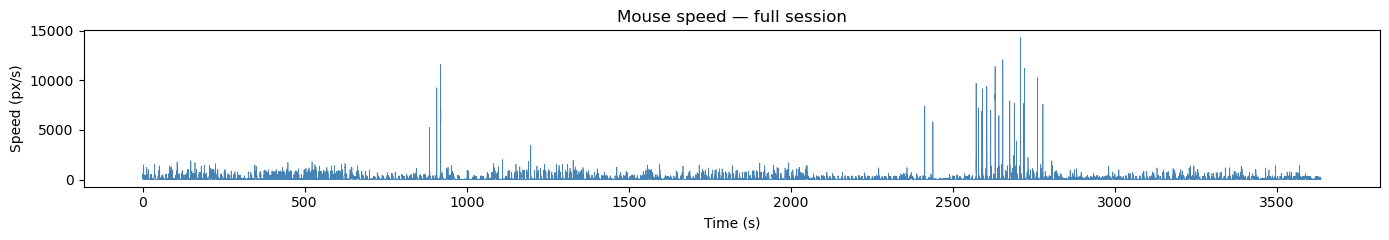

In [9]:
session_start_frame = int(sdf['frame_idx_global'].min())
session_end_frame   = int(sdf['frame_idx_global'].max())

print(f"Frame range: {session_start_frame} – {session_end_frame}  "
      f"({(session_end_frame - session_start_frame) / FPS:.1f} s)")

# summary_df has MultiIndex columns ('headstage', 'x') etc — pass as tuples
times_speed_rel, speed_global, _ = compute_path_speed(
    summary_df,
    session_start_frame,
    session_end_frame,
    x_col=('headstage', 'x'),
    y_col=('headstage', 'y'),
    frame_col='frame_idx_global',
    smooth_window_frames=SPEED_SMOOTH_FRAMES,
)

# Convert relative time to absolute seconds
t_speed_abs = times_speed_rel + session_start_frame / FPS

print(f"Speed samples: {len(speed_global)}  "
      f"(NaN: {np.isnan(speed_global).sum()})")

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.plot(t_speed_abs, speed_global, linewidth=0.5, color='steelblue')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed (px/s)')
ax.set_title('Mouse speed — full session')
plt.tight_layout()
plt.show()

## Firing-rate helpers

In [10]:
def get_all_spikes_abs(cluster_id):
    """All spike times (absolute seconds) for one unit across all maze trials."""
    chunks = []
    for t in trial_meta.index:
        st = np.asarray(maze_spike_times[t]).flatten() / FS
        sc = np.asarray(maze_spike_clusters[t]).flatten()
        t_abs = trial_meta.loc[t, 'start_abs'] + st
        chunks.append(t_abs[sc == cluster_id])
    return np.concatenate(chunks) if chunks else np.array([])


def compute_rate_on_axis(spike_times_abs, t_axis, sigma_s=RATE_SMOOTH_SIGMA_S):
    """Gaussian-smoothed firing rate (Hz) evaluated at the same time points as t_axis."""
    if len(t_axis) < 2:
        return np.zeros(len(t_axis))
    dt = np.median(np.diff(t_axis))
    # Bin edges centred on each sample
    edges = np.concatenate([
        [t_axis[0] - dt / 2],
        (t_axis[:-1] + t_axis[1:]) / 2,
        [t_axis[-1] + dt / 2],
    ])
    counts, _ = np.histogram(spike_times_abs, bins=edges)
    rate = counts.astype(float) / dt
    if sigma_s > 0:
        rate = gaussian_filter1d(rate, sigma=sigma_s / dt)
    return rate

## Compute correlations for all good + MUA units

We correlate over frames where speed is **not NaN** (tracking drop-outs are excluded).

In [11]:
all_units = pd.concat([
    good_units[['cluster_id']].assign(group='good'),
    mua_units[['cluster_id']].assign(group='mua'),
], ignore_index=True)

valid_speed_mask = ~np.isnan(speed_global)
MIN_VALID_SAMPLES = 200

corr_results = []
for i, row in all_units.iterrows():
    cid = int(row['cluster_id'])
    grp = row['group']

    spikes = get_all_spikes_abs(cid)
    rate   = compute_rate_on_axis(spikes, t_speed_abs)

    mask = valid_speed_mask
    if mask.sum() < MIN_VALID_SAMPLES:
        corr_results.append({'cluster_id': cid, 'group': grp, 'r': np.nan, 'p': np.nan})
        continue

    r, p = pearsonr(speed_global[mask], rate[mask])
    corr_results.append({'cluster_id': cid, 'group': grp, 'r': r, 'p': p})

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(all_units)} units done…")

corr_df = pd.DataFrame(corr_results).sort_values('r', ascending=False).reset_index(drop=True)
print(f"\nDone. {len(corr_df)} units.")
corr_df.head(20)

  10/171 units done…
  20/171 units done…
  30/171 units done…
  40/171 units done…
  50/171 units done…
  60/171 units done…
  70/171 units done…
  80/171 units done…
  90/171 units done…
  100/171 units done…
  110/171 units done…
  120/171 units done…
  130/171 units done…
  140/171 units done…
  150/171 units done…
  160/171 units done…
  170/171 units done…

Done. 171 units.


,cluster_id,group,r,p
0,193,good,0.172494,0.000000e+00
1,40,mua,0.153763,0.000000e+00
2,574,good,0.148582,0.000000e+00
3,600,mua,0.137759,0.000000e+00
4,386,mua,0.127369,0.000000e+00
5,27,mua,0.123598,0.000000e+00
6,785,mua,0.121189,0.000000e+00
7,170,mua,0.117991,0.000000e+00
8,157,mua,0.113623,0.000000e+00
9,553,mua,0.111149,0.000000e+00


## Correlation distribution — choose threshold

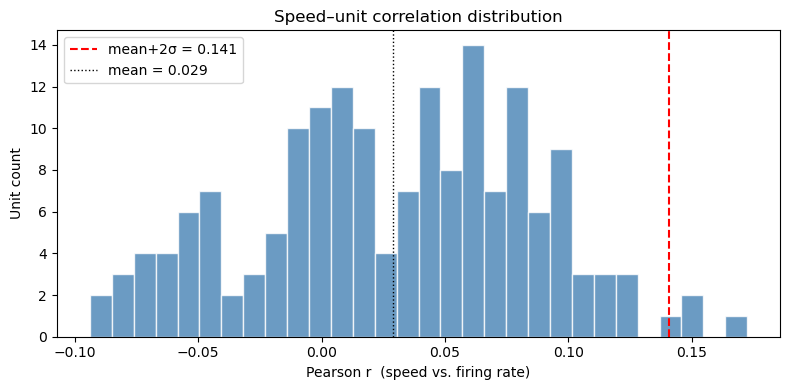

mean=0.029  σ=0.056  mean+2σ=0.141
Units above threshold: 3  (good: 2, mua: 1)


In [12]:
r_vals = corr_df['r'].dropna()

mu, sigma = r_vals.mean(), r_vals.std()
threshold_2sd = mu + 2 * sigma

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(threshold_2sd, color='red',    linestyle='--', linewidth=1.5,
           label=f'mean+2σ = {threshold_2sd:.3f}')
ax.axvline(mu,            color='black',  linestyle=':',  linewidth=1.0,
           label=f'mean = {mu:.3f}')
ax.set_xlabel('Pearson r  (speed vs. firing rate)')
ax.set_ylabel('Unit count')
ax.set_title('Speed–unit correlation distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"mean={mu:.3f}  σ={sigma:.3f}  mean+2σ={threshold_2sd:.3f}")
print(f"Units above threshold: {(r_vals > threshold_2sd).sum()}  "
      f"(good: {((corr_df['r'] > threshold_2sd) & (corr_df['group']=='good')).sum()}, "
      f"mua: {((corr_df['r'] > threshold_2sd) & (corr_df['group']=='mua')).sum()})")

In [13]:
# Adjust if the auto threshold is too permissive / strict
CORR_THRESHOLD = threshold_2sd   # ← edit manually after inspecting histogram

high_corr = corr_df[corr_df['r'] > CORR_THRESHOLD].reset_index(drop=True)
print(f"Units above threshold ({CORR_THRESHOLD:.3f}): {len(high_corr)}")
display(high_corr)

Units above threshold (0.141): 3


,cluster_id,group,r,p
0,193,good,0.172494,0.0
1,40,mua,0.153763,0.0
2,574,good,0.148582,0.0


## High-correlation units — random session window

A randomly chosen 60-second window shows speed and firing rate overlaid for each
unit above threshold.

Plotting 3 units, window 1380.0–1440.0 s


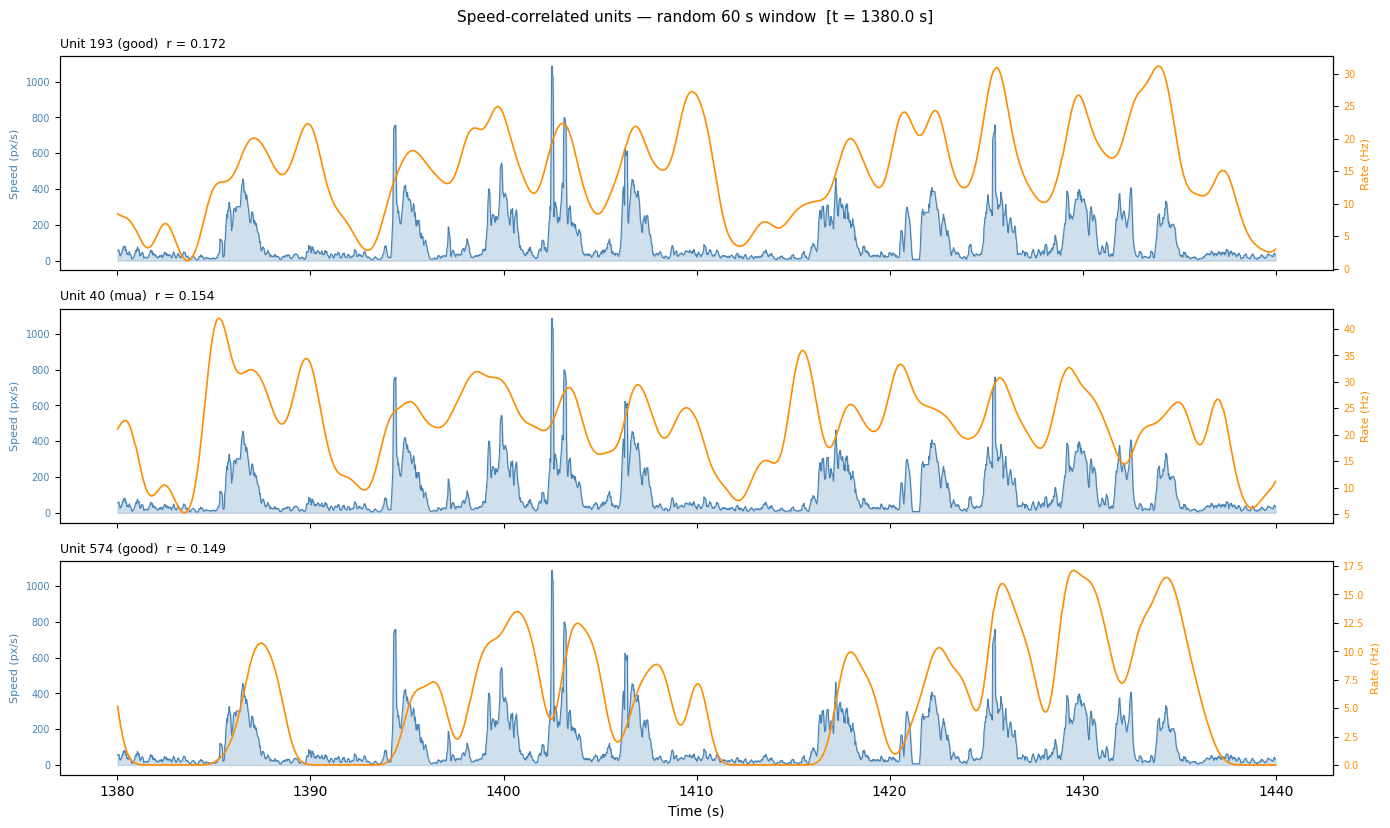

In [14]:
WINDOW_S    = 60.0
MAX_PANELS  = 10      # cap figure height

session_duration_s = t_speed_abs[-1] - t_speed_abs[0]
t_win_start = t_speed_abs[0] + random.uniform(0, max(0, session_duration_s - WINDOW_S))
t_win_end   = t_win_start + WINDOW_S

win_mask = (t_speed_abs >= t_win_start) & (t_speed_abs <= t_win_end)
t_win    = t_speed_abs[win_mask]
spd_win  = speed_global[win_mask]

units_to_plot = high_corr.head(MAX_PANELS)
n_panels = len(units_to_plot)
print(f"Plotting {n_panels} units, window {t_win_start:.1f}–{t_win_end:.1f} s")

if n_panels == 0:
    print("No units above threshold — lower CORR_THRESHOLD and re-run.")
else:
    fig, axes = plt.subplots(n_panels, 1,
                             figsize=(14, 2.8 * n_panels),
                             sharex=True)
    if n_panels == 1:
        axes = [axes]

    for ax, (_, urow) in zip(axes, units_to_plot.iterrows()):
        cid = int(urow['cluster_id'])
        spikes = get_all_spikes_abs(cid)
        rate_full = compute_rate_on_axis(spikes, t_speed_abs)
        rate_win  = rate_full[win_mask]

        ax2 = ax.twinx()
        ax.fill_between(t_win, spd_win, alpha=0.25, color='steelblue')
        ax.plot(t_win, spd_win, color='steelblue', linewidth=0.8)
        ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
        ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

        ax2.plot(t_win, rate_win, color='darkorange', linewidth=1.2)
        ax2.set_ylabel('Rate (Hz)', color='darkorange', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=7)

        ax.set_title(
            f"Unit {cid} ({urow['group']})  r = {urow['r']:.3f}",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"Speed-correlated units — random {int(WINDOW_S)} s window  "
        f"[t = {t_win_start:.1f} s]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

## Best-correlated time segments

A rolling Pearson r (window = `ROLLING_WINDOW_S` seconds, step = `ROLLING_STEP_S`
seconds) is computed for each top unit. The `TOP_SEGMENTS` non-overlapping windows
with the highest local r are extracted and plotted alongside the rolling-r trace.

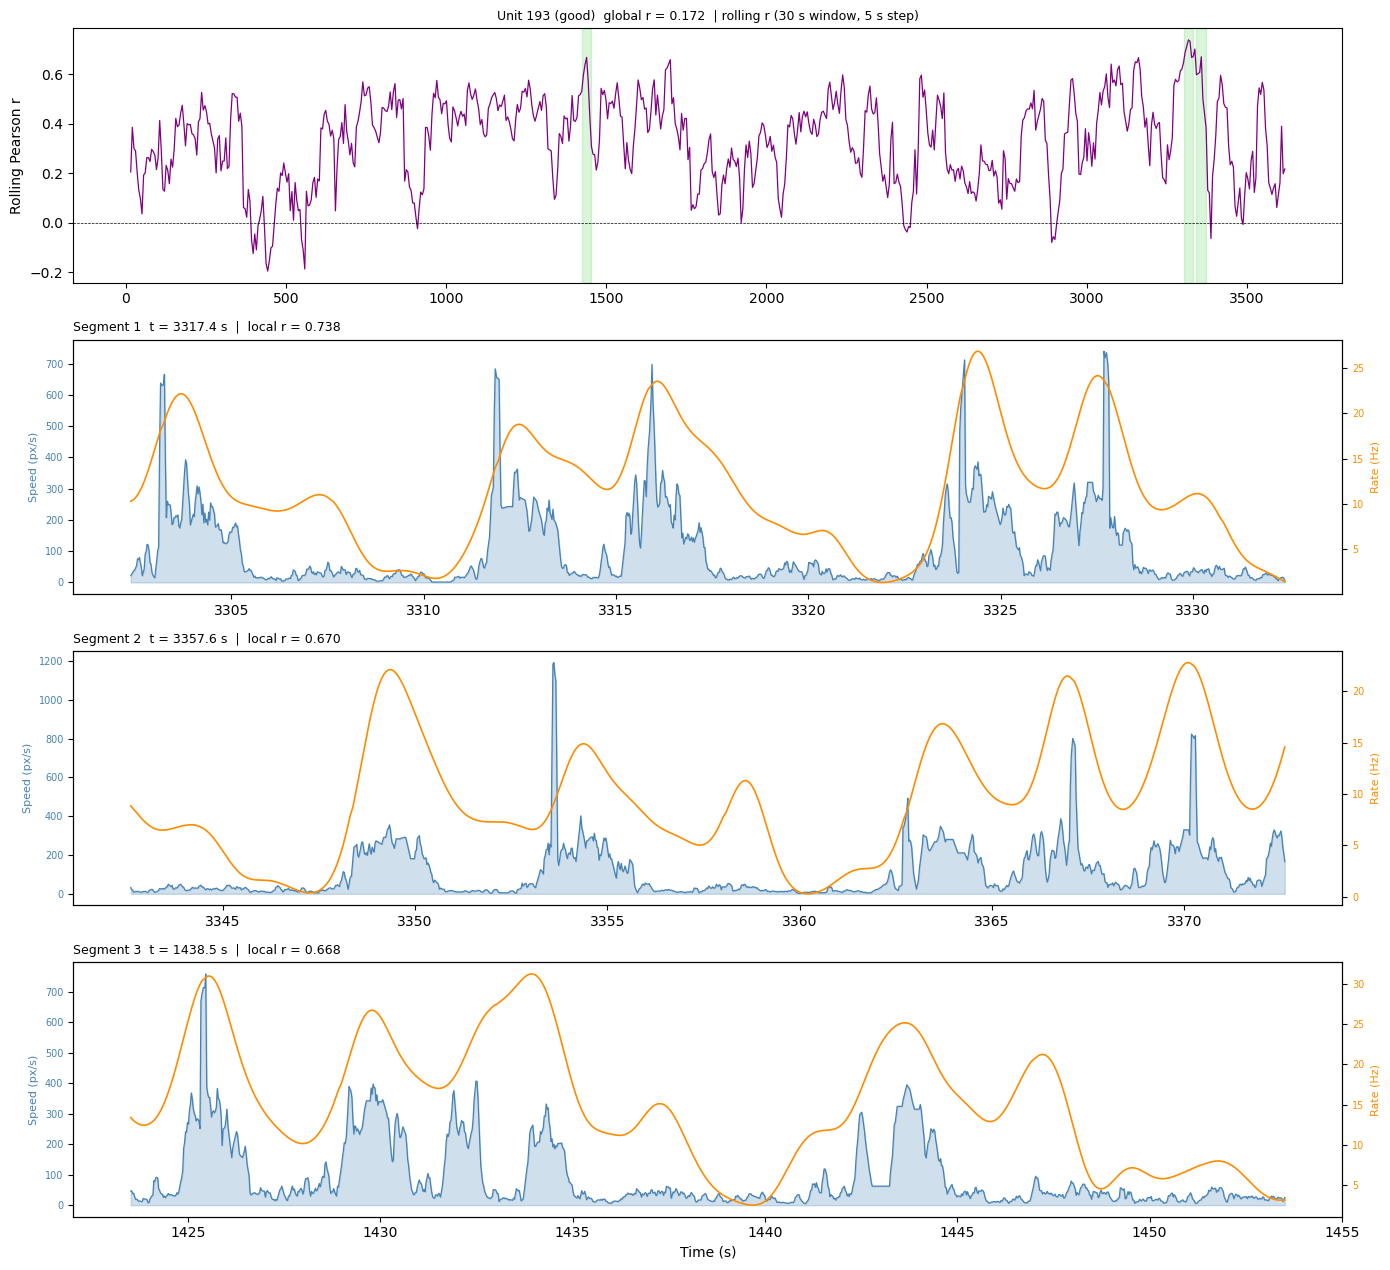

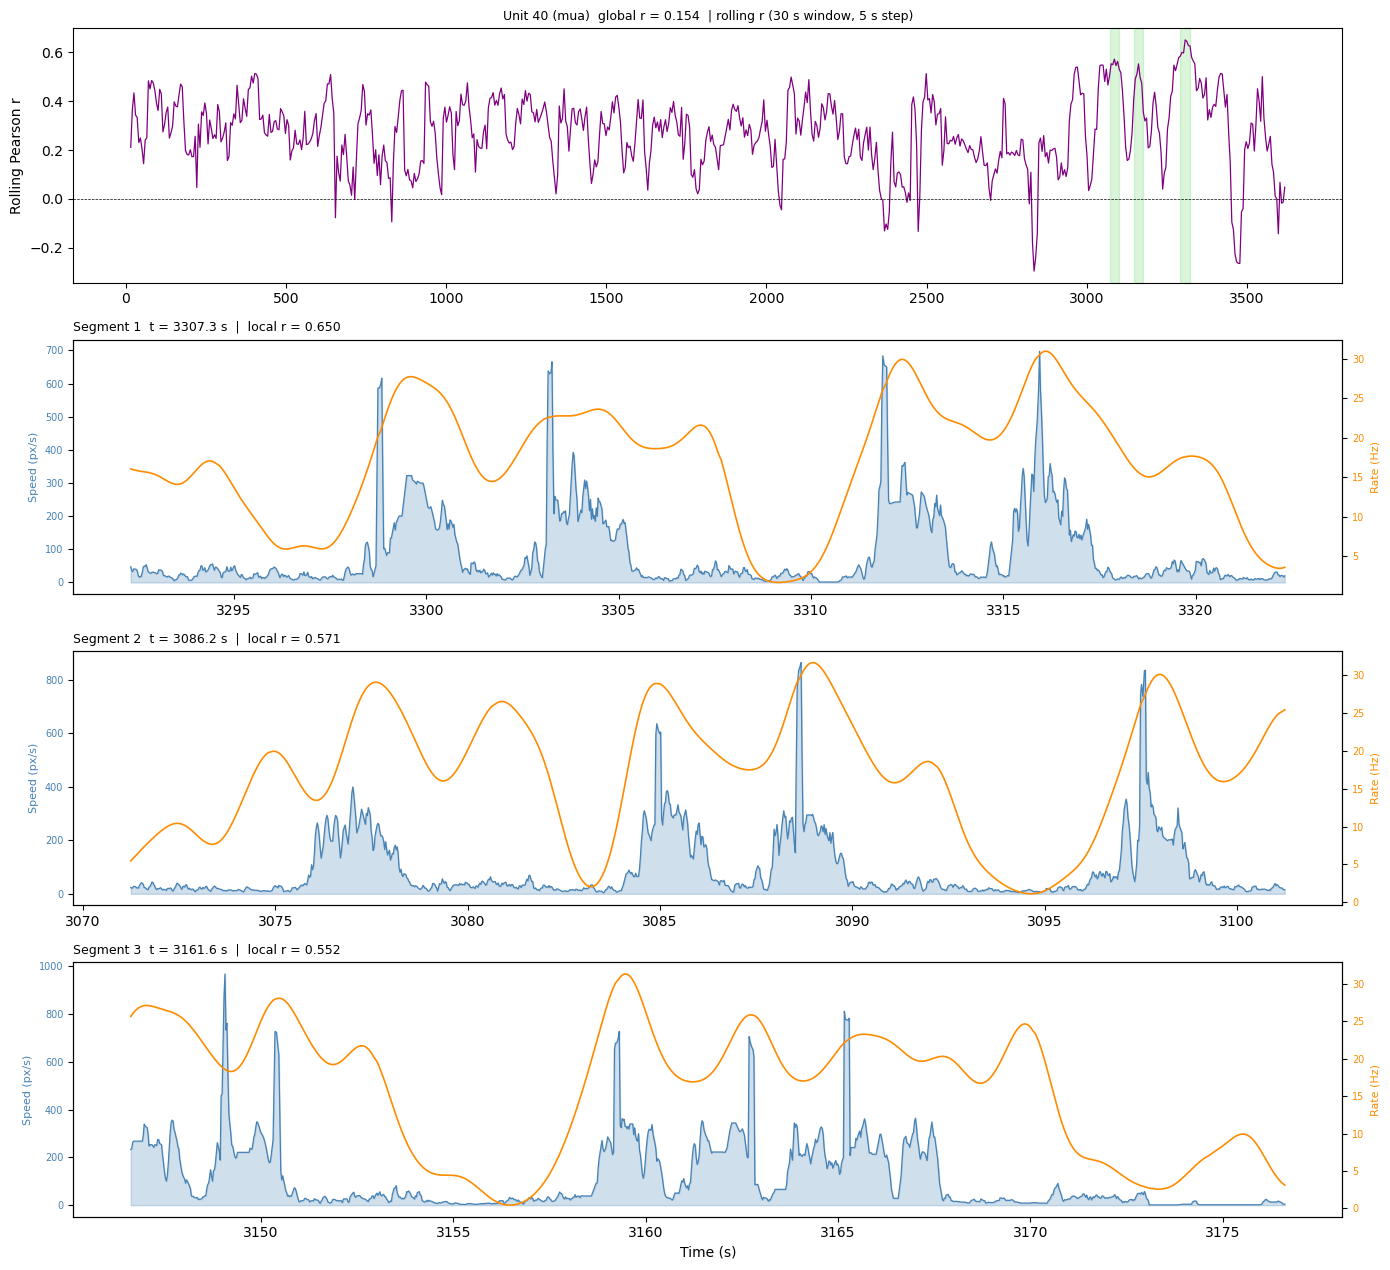

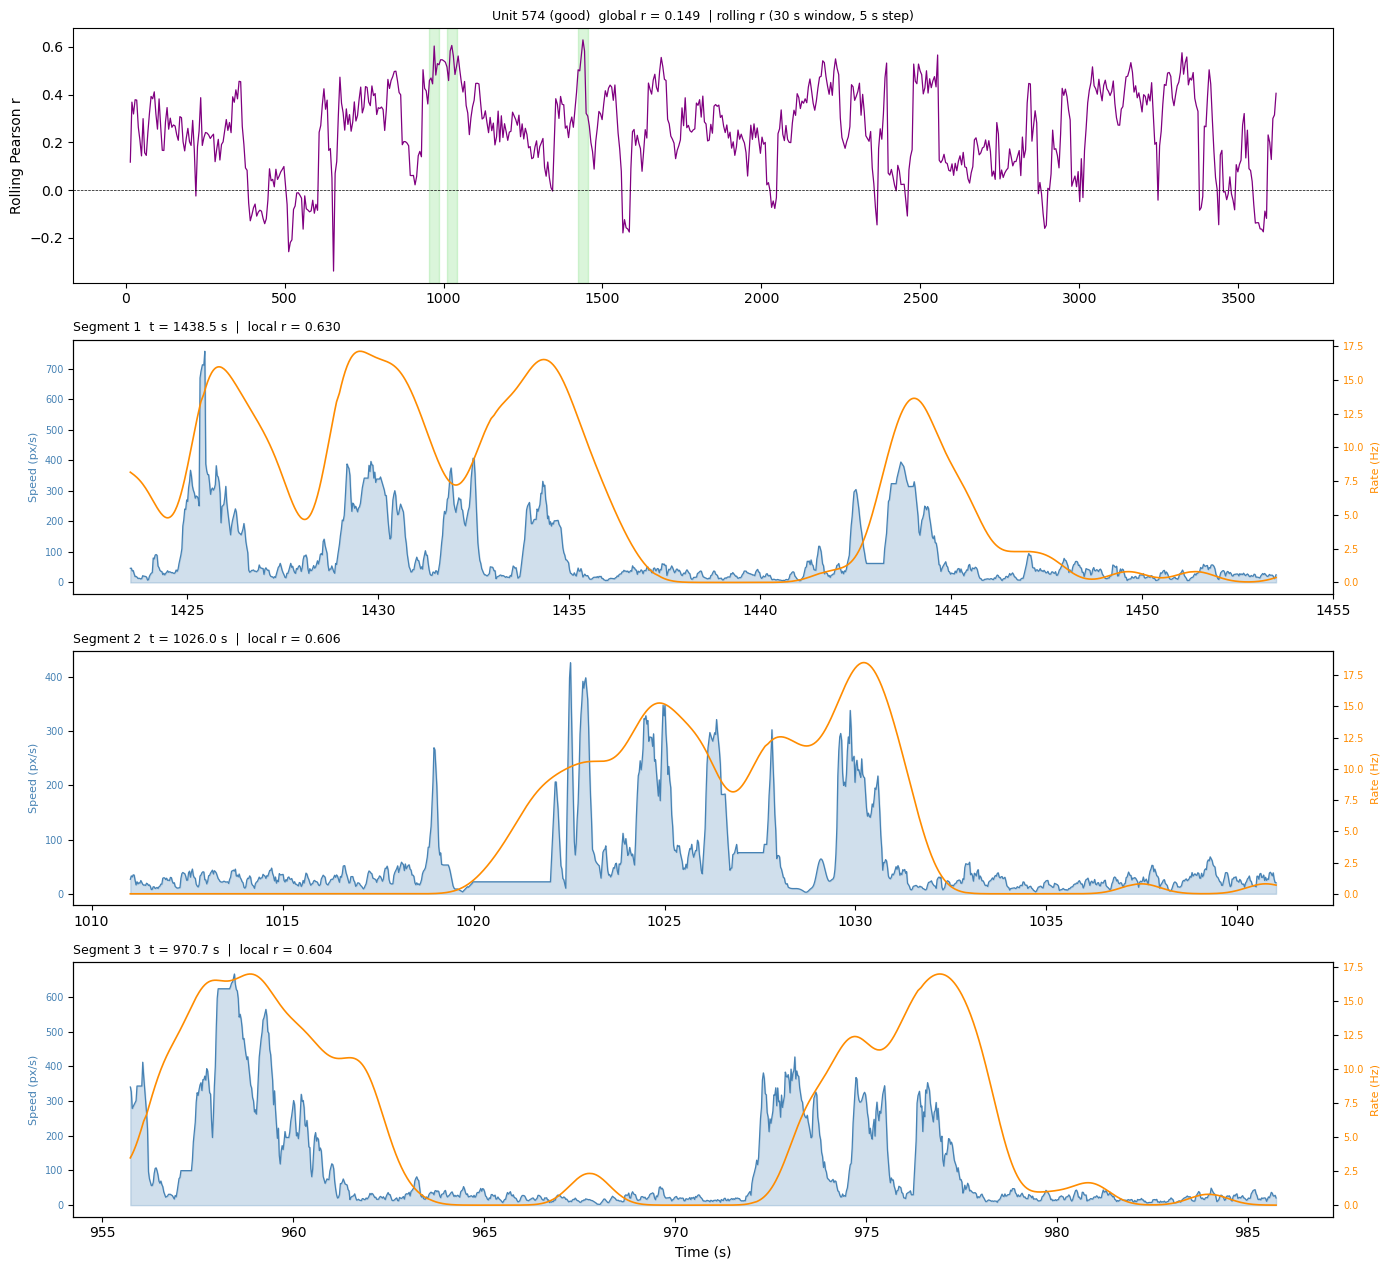

In [15]:
ROLLING_WINDOW_S = 30.0
ROLLING_STEP_S   = 5.0
TOP_SEGMENTS     = 3
MAX_UNITS_DETAIL = 5    # run detail plots for this many top units

dt_speed = float(np.median(np.diff(t_speed_abs)))
win_n    = max(2, int(round(ROLLING_WINDOW_S / dt_speed)))
step_n   = max(1, int(round(ROLLING_STEP_S   / dt_speed)))

# NaN-filled speed for rolling windows (use session median for gaps)
spd_filled = np.where(np.isnan(speed_global),
                      float(np.nanmedian(speed_global)),
                      speed_global)


def rolling_corr(rate_full):
    """Return (t_centers, r_values) for a sliding window over the session."""
    r_vals, t_cens = [], []
    for i in range(0, len(t_speed_abs) - win_n, step_n):
        s_seg = spd_filled[i:i + win_n]
        r_seg = rate_full[i:i + win_n]
        if np.std(s_seg) > 1e-9 and np.std(r_seg) > 1e-9:
            r_vals.append(np.corrcoef(s_seg, r_seg)[0, 1])
        else:
            r_vals.append(np.nan)
        t_cens.append(t_speed_abs[i + win_n // 2])
    return np.array(t_cens), np.array(r_vals)


def pick_top_segments(t_cens, r_vals, n=TOP_SEGMENTS):
    """Return center times of N non-overlapping windows with highest r."""
    order = np.argsort(np.where(np.isnan(r_vals), -np.inf, r_vals))[::-1]
    selected = []
    for idx in order:
        tc = t_cens[idx]
        if any(abs(tc - ts) < ROLLING_WINDOW_S for ts in selected):
            continue
        selected.append(tc)
        if len(selected) >= n:
            break
    return selected


units_detail = high_corr.head(MAX_UNITS_DETAIL)

for _, urow in units_detail.iterrows():
    cid = int(urow['cluster_id'])
    grp = urow['group']
    r_global = urow['r']

    spikes    = get_all_spikes_abs(cid)
    rate_full = compute_rate_on_axis(spikes, t_speed_abs)

    t_cens, r_roll = rolling_corr(rate_full)
    seg_centers     = pick_top_segments(t_cens, r_roll)

    n_segs = len(seg_centers)
    fig, axes = plt.subplots(1 + n_segs, 1,
                             figsize=(14, 3.2 * (1 + n_segs)))
    if 1 + n_segs == 1:
        axes = [axes]

    # --- rolling-r overview ---
    ax0 = axes[0]
    ax0.plot(t_cens, r_roll, color='purple', linewidth=0.9)
    ax0.axhline(0, color='black', linewidth=0.5, linestyle='--')
    for tc in seg_centers:
        ax0.axvspan(tc - ROLLING_WINDOW_S / 2, tc + ROLLING_WINDOW_S / 2,
                    alpha=0.18, color='limegreen')
    ax0.set_ylabel('Rolling Pearson r')
    ax0.set_title(
        f"Unit {cid} ({grp})  global r = {r_global:.3f}  "
        f"| rolling r ({int(ROLLING_WINDOW_S)} s window, {int(ROLLING_STEP_S)} s step)",
        fontsize=9
    )

    # --- per-segment detail ---
    for k, tc in enumerate(seg_centers):
        ax = axes[k + 1]
        t0 = tc - ROLLING_WINDOW_S / 2
        t1 = tc + ROLLING_WINDOW_S / 2
        seg_mask = (t_speed_abs >= t0) & (t_speed_abs <= t1)
        t_seg   = t_speed_abs[seg_mask]
        spd_seg = spd_filled[seg_mask]
        rt_seg  = rate_full[seg_mask]

        # local r from the rolling array
        closest = int(np.argmin(np.abs(t_cens - tc)))
        r_local = r_roll[closest]

        ax2 = ax.twinx()
        ax.fill_between(t_seg, spd_seg, alpha=0.25, color='steelblue')
        ax.plot(t_seg, spd_seg, color='steelblue', linewidth=0.9)
        ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
        ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

        ax2.plot(t_seg, rt_seg, color='darkorange', linewidth=1.2)
        ax2.set_ylabel('Rate (Hz)', color='darkorange', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=7)

        ax.set_title(
            f"Segment {k + 1}  t = {tc:.1f} s  |  local r = {r_local:.3f}",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

## Population-level analysis (PCA)

Build a **time × units** population rate matrix, z-score each unit, then run PCA.
For each PC we compute the Pearson correlation between the PC score trajectory and the
mouse speed.  PCs whose score co-varies with speed may reflect a movement-related
population signal even if no single unit clears the per-unit threshold.

In [16]:
# Build population rate matrix: shape (n_timepoints, n_units)
# Rows = video frames, columns = all good+mua units in the same order as all_units

n_time = len(t_speed_abs)
rate_matrix = np.zeros((n_time, len(all_units)), dtype=np.float32)

for i, (_, row) in enumerate(all_units.iterrows()):
    cid = int(row['cluster_id'])
    spikes = get_all_spikes_abs(cid)
    rate_matrix[:, i] = compute_rate_on_axis(spikes, t_speed_abs)
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(all_units)} units done…", end='\r')

print(f"\nRate matrix shape: {rate_matrix.shape}  "
      f"(~{rate_matrix.nbytes / 1e6:.0f} MB)")

  170/171 units done…
Rate matrix shape: (144685, 171)  (~99 MB)


In [17]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


 pc         r    abs_r             p  var_exp
  2  0.122892 0.122892  0.000000e+00 0.118701
 15  0.084657 0.084657 2.625901e-228 0.008302
  1  0.079816 0.079816 4.278867e-203 0.223072
  4 -0.076220 0.076220 2.439871e-185 0.026631
  6  0.062747 0.062747 3.820156e-126 0.018878
  3 -0.049915 0.049915  1.766583e-80 0.086359
 20 -0.047421 0.047421  8.210042e-73 0.006054
 14 -0.045399 0.045399  6.944723e-67 0.008501
 19 -0.038632 0.038632  6.448768e-49 0.006234
  7  0.037496 0.037496  3.499234e-46 0.016456
 13  0.036277 0.036277  2.440537e-43 0.009356
 12  0.021527 0.021527  2.628915e-16 0.009700
  5 -0.017922 0.017922  9.253345e-12 0.023757
 17 -0.015599 0.015599  2.962684e-09 0.007285
 18  0.014106 0.014106  8.055526e-08 0.006632
  8 -0.013705 0.013705  1.855153e-07 0.014114
 10  0.011746 0.011746  7.894268e-06 0.011935
  9  0.008075 0.008075  2.128870e-03 0.012447
 11  0.001505 0.001505  5.670408e-01 0.010774
 16  0.000213 0.000213  9.354428e-01 0.007463


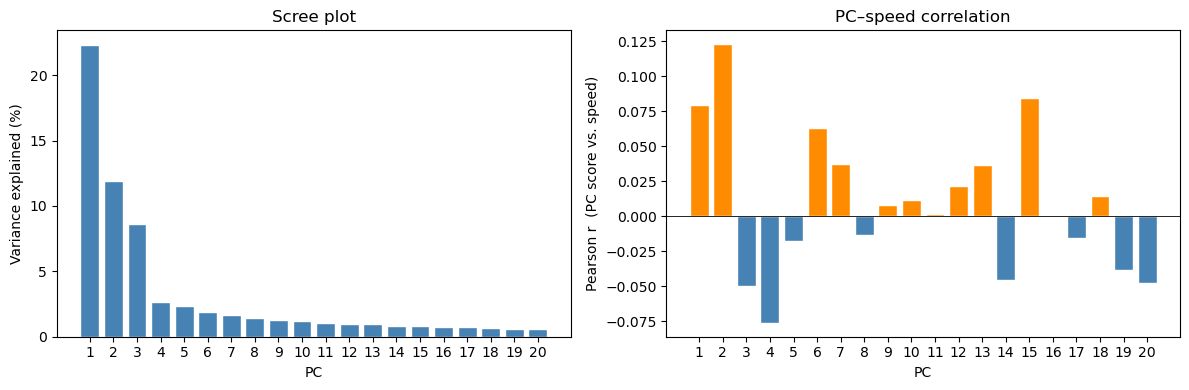

In [18]:
from sklearn.decomposition import PCA

N_COMPONENTS = min(20, len(all_units))

# Z-score each unit so high-firing units don't dominate the covariance
rate_z = (rate_matrix - rate_matrix.mean(axis=0)) / (rate_matrix.std(axis=0) + 1e-9)

pca = PCA(n_components=N_COMPONENTS)
pc_scores = pca.fit_transform(rate_z)   # (n_time, N_COMPONENTS)
var_exp   = pca.explained_variance_ratio_

# Correlate each PC score trajectory with speed (valid frames only)
valid_mask = ~np.isnan(speed_global)
pc_corr = []
for k in range(N_COMPONENTS):
    r, p = pearsonr(speed_global[valid_mask], pc_scores[valid_mask, k])
    pc_corr.append({'pc': k + 1, 'r': r, 'abs_r': abs(r), 'p': p,
                    'var_exp': var_exp[k]})

pc_corr_df = pd.DataFrame(pc_corr)
print(pc_corr_df.sort_values('abs_r', ascending=False).to_string(index=False))

# --- overview figure: scree + |r| bar chart ---
fig, (ax_var, ax_r) = plt.subplots(1, 2, figsize=(12, 4))

pcs = pc_corr_df['pc'].values

ax_var.bar(pcs, var_exp * 100, color='steelblue', edgecolor='white')
ax_var.set_xlabel('PC')
ax_var.set_ylabel('Variance explained (%)')
ax_var.set_title('Scree plot')
ax_var.set_xticks(pcs)

colors = ['darkorange' if r > 0 else 'steelblue' for r in pc_corr_df['r']]
ax_r.bar(pcs, pc_corr_df['r'].values, color=colors, edgecolor='white')
ax_r.axhline(0, color='black', linewidth=0.6)
ax_r.set_xlabel('PC')
ax_r.set_ylabel('Pearson r  (PC score vs. speed)')
ax_r.set_title('PC–speed correlation')
ax_r.set_xticks(pcs)

plt.tight_layout()
plt.show()

PCs with |r| > 0.1: 1


,pc,r,abs_r,p,var_exp
1,2,0.122892,0.122892,0.0,0.118701


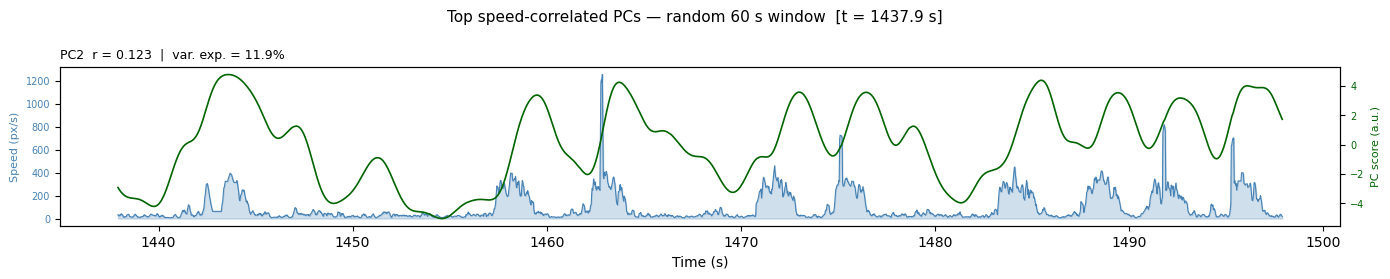

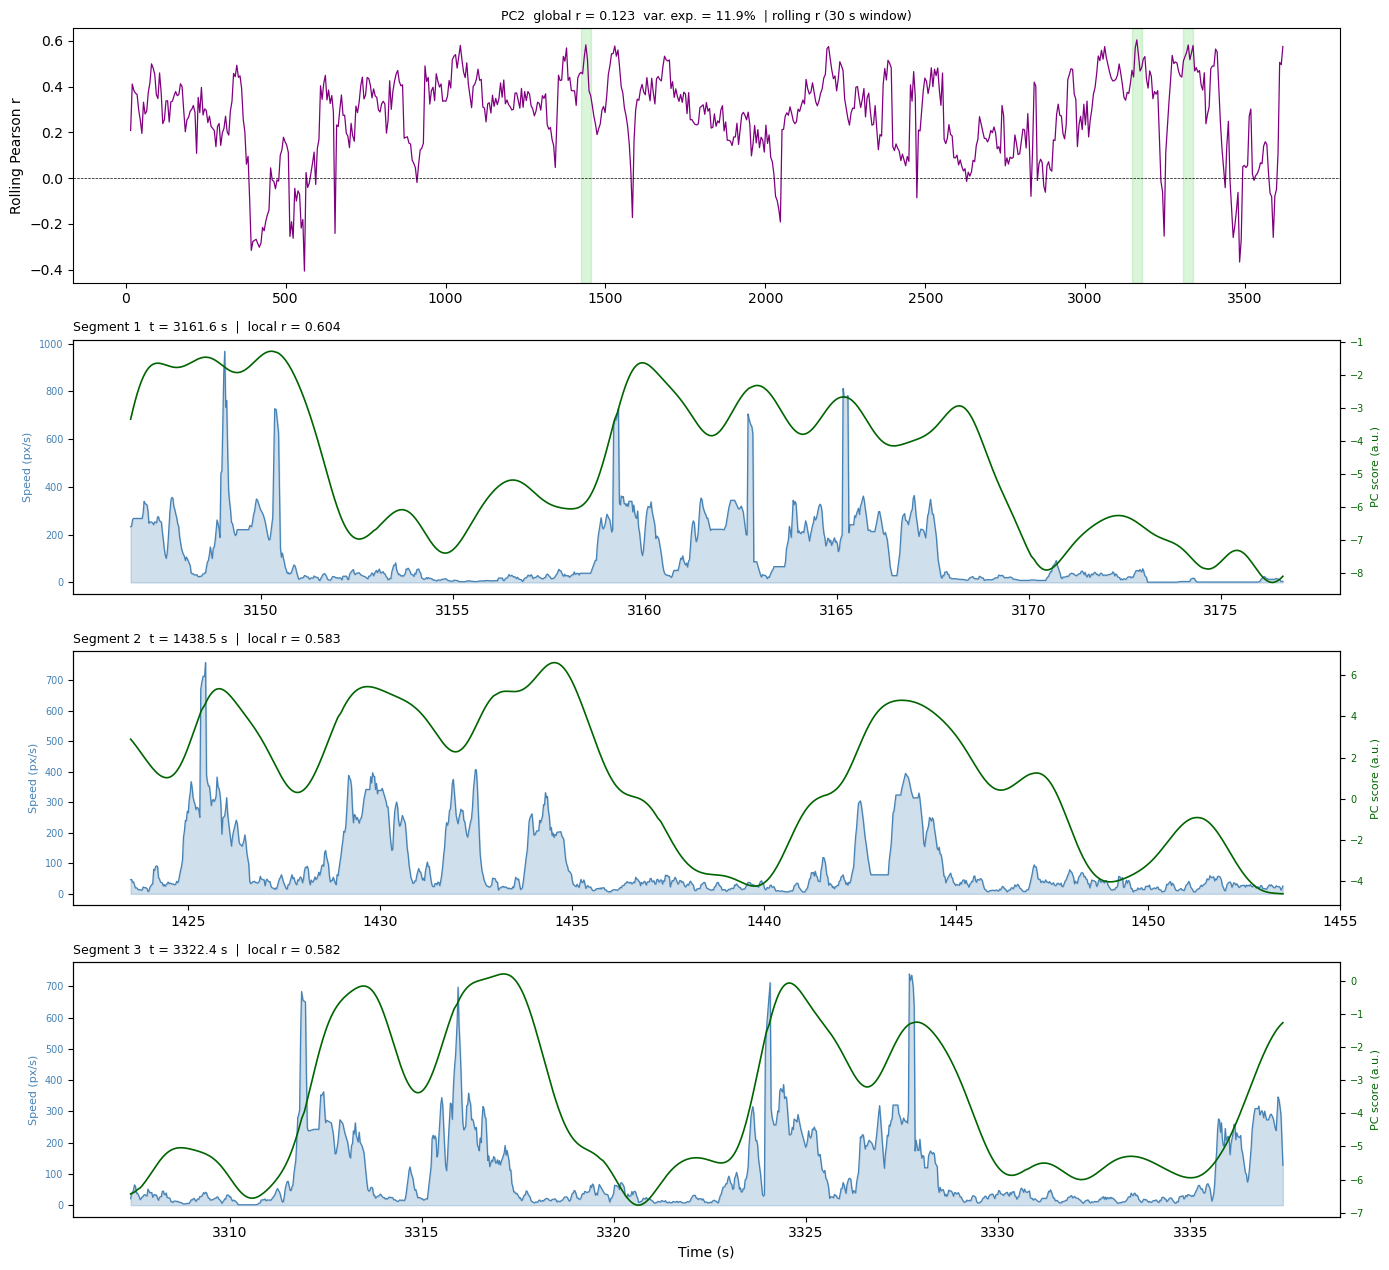

In [19]:
PC_CORR_THRESHOLD = 0.1   # |r| threshold — adjust after seeing the bar chart above
MAX_PC_DETAIL     = 5     # how many PCs to show detail plots for

top_pcs = (pc_corr_df[pc_corr_df['abs_r'] > PC_CORR_THRESHOLD]
           .sort_values('abs_r', ascending=False)
           .head(MAX_PC_DETAIL))

print(f"PCs with |r| > {PC_CORR_THRESHOLD}: {len(top_pcs)}")
display(top_pcs)

# --- random window overview (all top PCs stacked) ---
WINDOW_S_PC = 60.0
t_pc_start  = t_speed_abs[0] + random.uniform(
    0, max(0, (t_speed_abs[-1] - t_speed_abs[0]) - WINDOW_S_PC)
)
t_pc_end    = t_pc_start + WINDOW_S_PC
win_mask_pc = (t_speed_abs >= t_pc_start) & (t_speed_abs <= t_pc_end)
t_win_pc    = t_speed_abs[win_mask_pc]
spd_win_pc  = speed_global[win_mask_pc]

n_pc_panels = len(top_pcs)
if n_pc_panels == 0:
    print("No PCs above threshold — lower PC_CORR_THRESHOLD and re-run.")
else:
    fig, axes = plt.subplots(n_pc_panels, 1,
                             figsize=(14, 2.8 * n_pc_panels),
                             sharex=True)
    if n_pc_panels == 1:
        axes = [axes]

    for ax, (_, prow) in zip(axes, top_pcs.iterrows()):
        k    = int(prow['pc']) - 1
        r_pc = prow['r']
        score_win = pc_scores[win_mask_pc, k]

        ax2 = ax.twinx()
        ax.fill_between(t_win_pc, spd_win_pc, alpha=0.25, color='steelblue')
        ax.plot(t_win_pc, spd_win_pc, color='steelblue', linewidth=0.8)
        ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
        ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

        ax2.plot(t_win_pc, score_win, color='darkgreen', linewidth=1.2)
        ax2.set_ylabel('PC score (a.u.)', color='darkgreen', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=7)

        ax.set_title(
            f"PC{k + 1}  r = {r_pc:.3f}  |  var. exp. = {prow['var_exp']*100:.1f}%",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"Top speed-correlated PCs — random {int(WINDOW_S_PC)} s window  "
        f"[t = {t_pc_start:.1f} s]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    # --- rolling correlation + best segments for each top PC ---
    for _, prow in top_pcs.iterrows():
        k        = int(prow['pc']) - 1
        r_global = prow['r']
        score    = pc_scores[:, k]

        t_cens, r_roll = rolling_corr(score)   # reuse helper from above
        seg_centers    = pick_top_segments(t_cens, r_roll)

        n_segs = len(seg_centers)
        fig, axes = plt.subplots(1 + n_segs, 1,
                                 figsize=(14, 3.2 * (1 + n_segs)))
        if 1 + n_segs == 1:
            axes = [axes]

        ax0 = axes[0]
        ax0.plot(t_cens, r_roll, color='purple', linewidth=0.9)
        ax0.axhline(0, color='black', linewidth=0.5, linestyle='--')
        for tc in seg_centers:
            ax0.axvspan(tc - ROLLING_WINDOW_S / 2, tc + ROLLING_WINDOW_S / 2,
                        alpha=0.18, color='limegreen')
        ax0.set_ylabel('Rolling Pearson r')
        ax0.set_title(
            f"PC{k + 1}  global r = {r_global:.3f}  var. exp. = {prow['var_exp']*100:.1f}%  "
            f"| rolling r ({int(ROLLING_WINDOW_S)} s window)",
            fontsize=9
        )

        for j, tc in enumerate(seg_centers):
            ax  = axes[j + 1]
            t0  = tc - ROLLING_WINDOW_S / 2
            t1  = tc + ROLLING_WINDOW_S / 2
            seg_mask = (t_speed_abs >= t0) & (t_speed_abs <= t1)
            t_seg    = t_speed_abs[seg_mask]
            spd_seg  = spd_filled[seg_mask]
            sc_seg   = score[seg_mask]

            closest = int(np.argmin(np.abs(t_cens - tc)))
            r_local = r_roll[closest]

            ax2 = ax.twinx()
            ax.fill_between(t_seg, spd_seg, alpha=0.25, color='steelblue')
            ax.plot(t_seg, spd_seg, color='steelblue', linewidth=0.9)
            ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
            ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

            ax2.plot(t_seg, sc_seg, color='darkgreen', linewidth=1.2)
            ax2.set_ylabel('PC score (a.u.)', color='darkgreen', fontsize=8)
            ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=7)

            ax.set_title(
                f"Segment {j + 1}  t = {tc:.1f} s  |  local r = {r_local:.3f}",
                fontsize=9, loc='left'
            )

        axes[-1].set_xlabel('Time (s)')
        plt.tight_layout()
        plt.show()

---

## Turn-event speed correlation (units & PCs)

Same Pearson-r analysis as above, restricted to ±`TURN_WIN_S` second windows around
each turn event from `turn_df.csv`.  
Two timing references are compared throughout:
- **Midpoint**: `(start_frame_global + end_frame_global) / 2 / FPS` — available for all turns  
- **Refined**: `refined_turn_frame_global / FPS` — filtered by `turn_confidence ≥ MIN_TURN_CONFIDENCE`

A spatial analysis also shows mean speed as a function of Euclidean distance from the turn point.

In [20]:
TURN_WIN_S          = 0.5    # half-window around each turn event (seconds)
MIN_TURN_CONFIDENCE = 0.3    # kept for reference; not used to filter turns below
TURN_TYPES          = None   # None = all; or e.g. ['LEFT', 'RIGHT']

turn_df_path = (
    f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/"
    f"resources/outputs/{DD_MM_YYYY}/turn_df.csv"
)
turn_df = pd.read_csv(turn_df_path)
if TURN_TYPES:
    turn_df = turn_df[turn_df['turn_type'].isin(TURN_TYPES)].copy()
else:
    turn_df = turn_df.copy()

# Midpoint heuristic — available for every row
turn_df['t_midpoint_abs'] = (
    (turn_df['start_frame_global'] + turn_df['end_frame_global']) / 2 / FPS
)
turn_df['midpoint_frame'] = (
    ((turn_df['start_frame_global'] + turn_df['end_frame_global']) / 2).round().astype(int)
)

# Refined timing — all turns with a valid refined frame (no confidence filter,
# so both methods cover the same population where comparable)
turn_refined = turn_df[turn_df['refined_turn_frame_global'].notna()].copy()
turn_refined['t_refined_abs'] = turn_refined['refined_turn_frame_global'] / FPS

print(f"All turn rows   (midpoint): {len(turn_df)}")
print(f"Valid refined turns:        {len(turn_refined)}")
print(turn_df['turn_type'].value_counts().to_string())

All turn rows   (midpoint): 4334
Valid refined turns:        2706
turn_type
LEFT        1438
RIGHT       1409
UTURN       1136
STRAIGHT     351


In [21]:
def _build_turn_mask(t_events, t_axis, half_win):
    """True for every t_axis sample within half_win seconds of any event."""
    t_events = np.sort(np.asarray(t_events, dtype=float))
    mask = np.zeros(len(t_axis), dtype=bool)
    lo = np.searchsorted(t_axis, t_events - half_win)
    hi = np.searchsorted(t_axis, t_events + half_win, side='right')
    for l, h in zip(lo, hi):
        if l < h:
            mask[l:h] = True
    return mask


valid_speed = ~np.isnan(speed_global)

mask_midpoint = _build_turn_mask(turn_df['t_midpoint_abs'], t_speed_abs, TURN_WIN_S) & valid_speed
mask_refined  = _build_turn_mask(turn_refined['t_refined_abs'], t_speed_abs, TURN_WIN_S) & valid_speed

print(f"Midpoint mask: {mask_midpoint.sum():,} samples ({100 * mask_midpoint.mean():.1f}%)")
print(f"Refined mask:  {mask_refined.sum():,} samples ({100 * mask_refined.mean():.1f}%)")

Midpoint mask: 76,426 samples (52.8%)
Refined mask:  67,920 samples (46.9%)


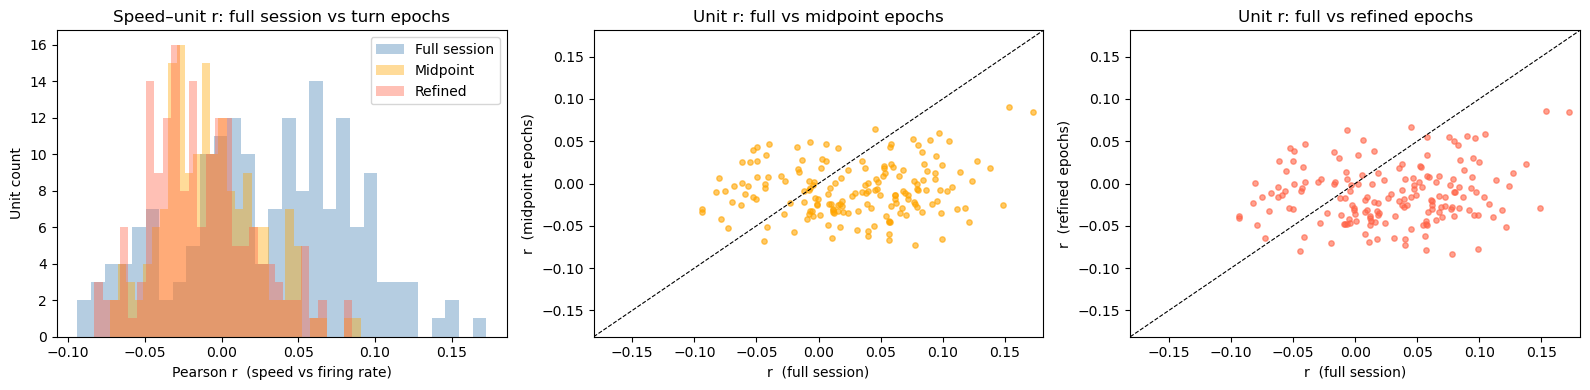

Top units by r (refined turn epochs):


,cluster_id,group,r,p
0,40,mua,0.085190,1.356101e-109
1,193,good,0.084993,4.266489e-109
2,177,mua,0.066644,1.027717e-67
3,706,mua,0.063790,3.509014e-62
4,372,mua,0.058690,6.712399e-53
5,744,mua,0.056007,2.522782e-48
6,370,mua,0.055086,8.339304e-47
7,207,mua,0.054879,1.818135e-46
8,96,good,0.053727,1.316447e-44
9,167,mua,0.051786,1.462259e-41


In [22]:
def _unit_corr_masked(mask):
    """Pearson r between speed and firing rate for each unit, restricted to mask."""
    results = []
    n_valid = int(mask.sum())
    for i, row in all_units.iterrows():
        cid = int(row['cluster_id'])
        grp = row['group']
        if n_valid < MIN_VALID_SAMPLES:
            results.append({'cluster_id': cid, 'group': grp, 'r': np.nan, 'p': np.nan})
            continue
        r, p = pearsonr(speed_global[mask], rate_matrix[mask, i])
        results.append({'cluster_id': cid, 'group': grp, 'r': r, 'p': p})
    return pd.DataFrame(results).sort_values('r', ascending=False).reset_index(drop=True)


turn_corr_mid = _unit_corr_masked(mask_midpoint)
turn_corr_ref = _unit_corr_masked(mask_refined)

# 3-panel figure: overlapping histograms + full-vs-turn scatter (×2)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for df_, label, color in [
    (corr_df,       'Full session', 'steelblue'),
    (turn_corr_mid, 'Midpoint',     'orange'),
    (turn_corr_ref, 'Refined',      'tomato'),
]:
    ax.hist(df_['r'].dropna(), bins=30, alpha=0.4, label=label, color=color)
ax.set_xlabel('Pearson r  (speed vs firing rate)')
ax.set_ylabel('Unit count')
ax.set_title('Speed–unit r: full session vs turn epochs')
ax.legend()

for ax, turn_df_, col, label, color in [
    (axes[1], turn_corr_mid, 'r_mid', 'midpoint epochs', 'orange'),
    (axes[2], turn_corr_ref, 'r_ref', 'refined epochs',  'tomato'),
]:
    m = (corr_df[['cluster_id', 'r']].rename(columns={'r': 'r_full'})
         .merge(turn_df_[['cluster_id', 'r']].rename(columns={'r': col}), on='cluster_id'))
    lim = np.nanmax(np.abs(m[['r_full', col]].values)) * 1.05
    ax.scatter(m['r_full'], m[col], s=15, alpha=0.6, color=color)
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8)
    ax.set_xlabel('r  (full session)')
    ax.set_ylabel(f'r  ({label})')
    ax.set_title(f'Unit r: full vs {label}')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

plt.tight_layout()
plt.show()

print("Top units by r (refined turn epochs):")
display(turn_corr_ref.head(10))

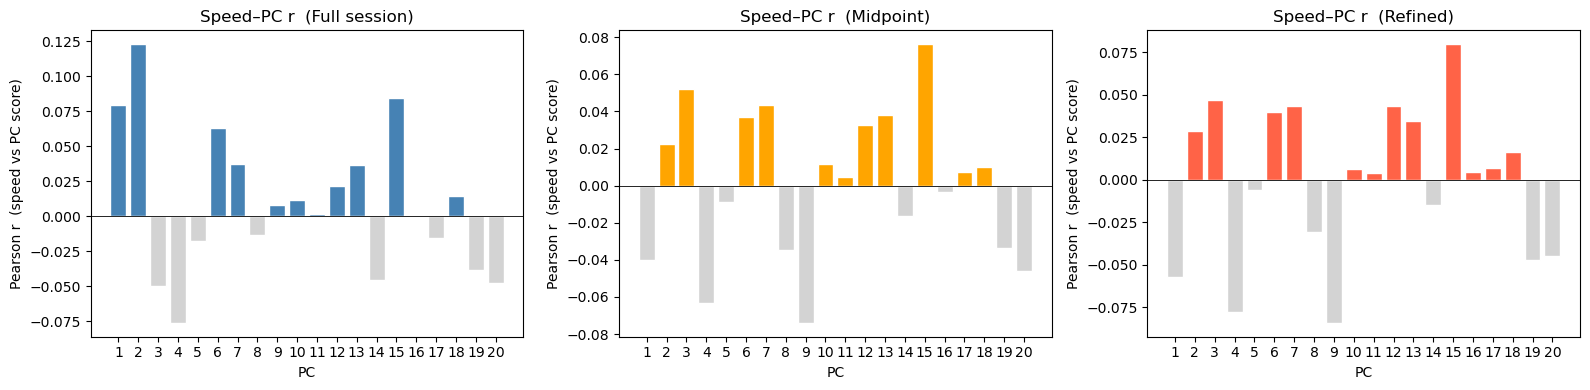

Top PCs by |r| (refined turn epochs):


,pc,r,abs_r,p,var_exp
0,9,-0.084121,0.084121,6.709296e-107,0.012447
1,15,0.079757,0.079757,2.927477e-96,0.008302
2,4,-0.077657,0.077657,2.420085e-91,0.026631
3,1,-0.057081,0.057081,3.945627e-50,0.223072
4,3,0.047026,0.047026,1.443801e-34,0.086359
5,19,-0.046886,0.046886,2.267477e-34,0.006234
6,20,-0.044671,0.044671,2.363496e-31,0.006054
7,7,0.043386,0.043386,1.143178e-29,0.016456
8,12,0.043336,0.043336,1.327538e-29,0.009700
9,6,0.040109,0.040109,1.361373e-25,0.018878


In [23]:
def _pc_corr_masked(mask):
    """Pearson r between speed and each PC score, restricted to mask."""
    results = []
    for k in range(N_COMPONENTS):
        r, p = pearsonr(speed_global[mask], pc_scores[mask, k])
        results.append({'pc': k + 1, 'r': r, 'abs_r': abs(r), 'p': p,
                        'var_exp': var_exp[k]})
    return pd.DataFrame(results).sort_values('abs_r', ascending=False).reset_index(drop=True)


turn_pc_mid = _pc_corr_masked(mask_midpoint)
turn_pc_ref = _pc_corr_masked(mask_refined)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df_, title, color in [
    (axes[0], pc_corr_df,  'Full session', 'steelblue'),
    (axes[1], turn_pc_mid, 'Midpoint',     'orange'),
    (axes[2], turn_pc_ref, 'Refined',      'tomato'),
]:
    ordered     = df_.sort_values('pc')
    pcs         = ordered['pc'].values
    rs          = ordered['r'].values
    bar_colors  = [color if r >= 0 else 'lightgray' for r in rs]
    ax.bar(pcs, rs, color=bar_colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel('PC')
    ax.set_ylabel('Pearson r  (speed vs PC score)')
    ax.set_title(f'Speed–PC r  ({title})')
    ax.set_xticks(pcs)

plt.tight_layout()
plt.show()

print("Top PCs by |r| (refined turn epochs):")
display(turn_pc_ref.head(10))

Computing speed-by-distance profiles…
Done.


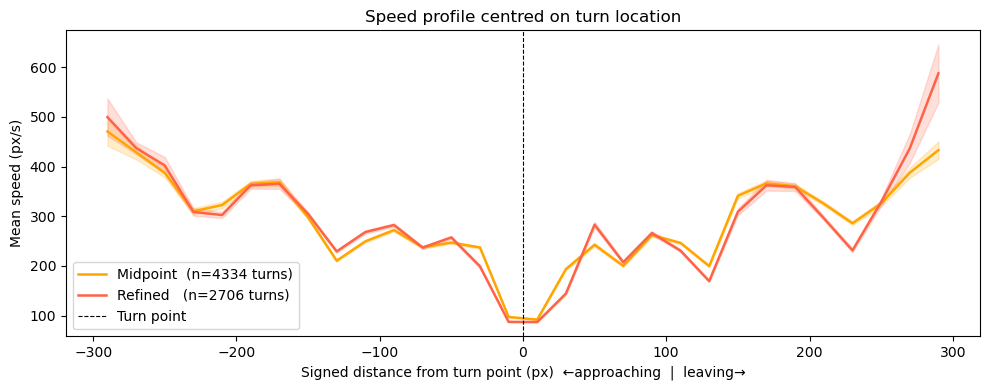

In [24]:
DIST_BIN_PX = 20     # spatial bin width (pixels)
MAX_DIST_PX = 300    # half-range: plot from -MAX_DIST_PX to +MAX_DIST_PX (pixels)
DIST_WIN_S  = 1.0    # time window around each turn used to build the profile

# Pre-build a frame → position lookup from sdf (already flattened in Cell 10)
_pos = sdf[['frame_idx_global', 'headstage_x', 'headstage_y']].dropna(
    subset=['headstage_x', 'headstage_y'])
frame_to_x = _pos.set_index('frame_idx_global')['headstage_x'].to_dict()
frame_to_y = _pos.set_index('frame_idx_global')['headstage_y'].to_dict()

# Global frame index for every speed sample (midpoint of consecutive-frame interval)
t_frames_global = np.round(t_speed_abs * FPS).astype(int)
pos_x = np.array([frame_to_x.get(int(f), np.nan) for f in t_frames_global])
pos_y = np.array([frame_to_y.get(int(f), np.nan) for f in t_frames_global])

# Signed-distance bins: negative = before turn time (approaching), positive = after (leaving)
dist_bins   = np.arange(-MAX_DIST_PX, MAX_DIST_PX + DIST_BIN_PX, DIST_BIN_PX)
bin_centers = (dist_bins[:-1] + dist_bins[1:]) / 2


def _speed_by_distance(turn_t_col, turn_frame_col):
    """Mean speed ± SEM vs signed distance from turn point.

    Sign is determined by time relative to the turn:
      negative → sample recorded before the turn (approaching)
      positive → sample recorded after the turn (leaving)
    """
    bin_speeds = [[] for _ in range(len(dist_bins) - 1)]
    for t_turn, f_turn in zip(turn_t_col, turn_frame_col):
        f_turn = int(round(f_turn))
        tx = frame_to_x.get(f_turn)
        ty = frame_to_y.get(f_turn)
        if tx is None or ty is None:
            continue
        win_idx = np.where(np.abs(t_speed_abs - t_turn) <= DIST_WIN_S)[0]
        px   = pos_x[win_idx]
        py   = pos_y[win_idx]
        spd  = speed_global[win_idx]
        t_w  = t_speed_abs[win_idx]
        dists = np.sqrt((px - tx) ** 2 + (py - ty) ** 2)
        # Negative sign for samples before the turn time
        signed = np.where(t_w < t_turn, -dists, dists)
        valid  = ~(np.isnan(signed) | np.isnan(spd))
        for sd, s in zip(signed[valid], spd[valid]):
            b = np.searchsorted(dist_bins, sd, side='right') - 1
            if 0 <= b < len(bin_speeds):
                bin_speeds[b].append(s)
    means = [np.nanmean(b) if b else np.nan for b in bin_speeds]
    sems  = [np.nanstd(b) / np.sqrt(len(b)) if len(b) > 1 else np.nan for b in bin_speeds]
    return np.array(means), np.array(sems)


print("Computing speed-by-distance profiles…")
mean_mid, sem_mid = _speed_by_distance(turn_df['t_midpoint_abs'], turn_df['midpoint_frame'])
mean_ref, sem_ref = _speed_by_distance(
    turn_refined['t_refined_abs'], turn_refined['refined_turn_frame_global'])
print("Done.")

fig, ax = plt.subplots(figsize=(10, 4))
for means, sems, label, color in [
    (mean_mid, sem_mid, f'Midpoint  (n={len(turn_df)} turns)',      'orange'),
    (mean_ref, sem_ref, f'Refined   (n={len(turn_refined)} turns)', 'tomato'),
]:
    ax.plot(bin_centers, means, color=color, linewidth=1.8, label=label)
    ax.fill_between(bin_centers, means - sems, means + sems, color=color, alpha=0.2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', label='Turn point')
ax.set_xlabel('Signed distance from turn point (px)  ←approaching  |  leaving→')
ax.set_ylabel('Mean speed (px/s)')
ax.set_title('Speed profile centred on turn location')
ax.legend()
plt.tight_layout()
plt.show()

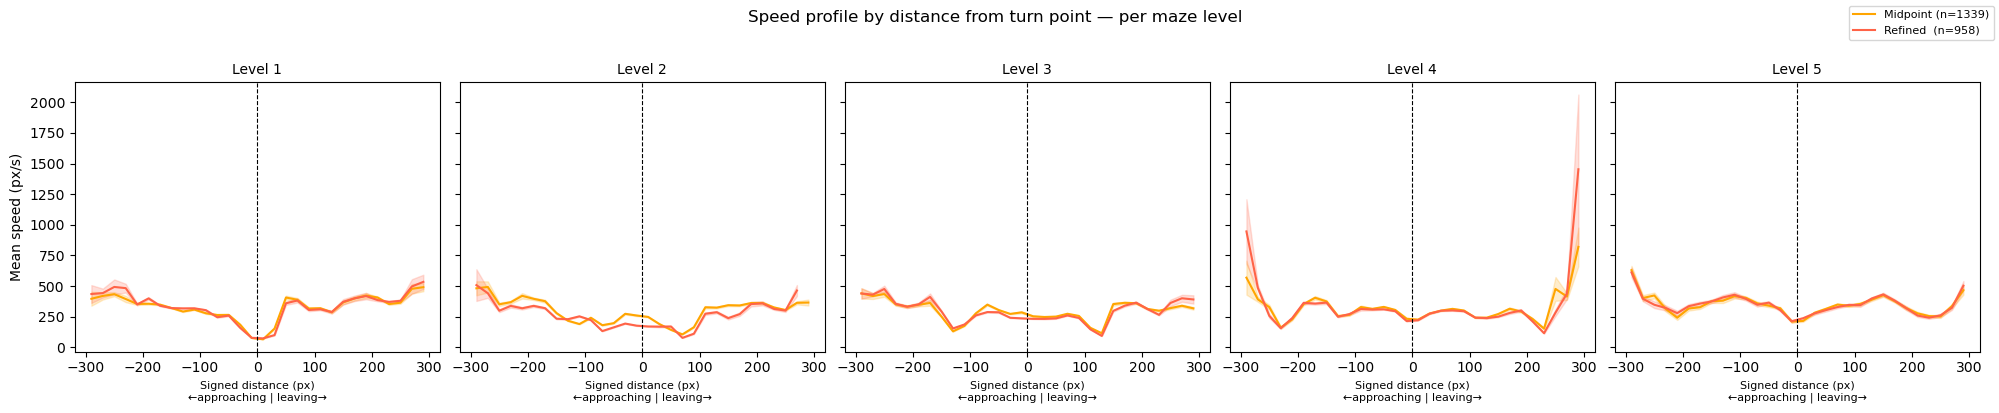

In [25]:
levels = sorted(turn_df['curr_node_level'].dropna().unique())
n_levels = len(levels)

fig, axes = plt.subplots(1, n_levels, figsize=(4 * n_levels, 4), sharey=True)
if n_levels == 1:
    axes = [axes]

for ax, lvl in zip(axes, levels):
    td_lvl  = turn_df[turn_df['curr_node_level'] == lvl]
    tr_lvl  = turn_refined[turn_refined['curr_node_level'] == lvl]

    for t_col, f_col, df_lvl, label, color in [
        ('t_midpoint_abs', 'midpoint_frame',            td_lvl, f'Midpoint (n={len(td_lvl)})', 'orange'),
        ('t_refined_abs',  'refined_turn_frame_global', tr_lvl, f'Refined  (n={len(tr_lvl)})', 'tomato'),
    ]:
        if df_lvl.empty:
            continue
        means, sems = _speed_by_distance(df_lvl[t_col], df_lvl[f_col])
        ax.plot(bin_centers, means, color=color, linewidth=1.5, label=label)
        ax.fill_between(bin_centers, means - sems, means + sems, color=color, alpha=0.2)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Level {int(lvl)}', fontsize=10)
    ax.set_xlabel('Signed distance (px)\n←approaching | leaving→', fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel('Mean speed (px/s)')

handles, labels = axes[0].get_legend_handles_labels()
if not handles:
    handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=8)
fig.suptitle('Speed profile by distance from turn point — per maze level', y=1.02)
plt.tight_layout()
plt.show()

---

## Angular Velocity – Unit & Population Correlation Analysis

Same pipeline as the speed analysis above, but using the **instantaneous angular
velocity** of the mouse's heading direction (rad/s; positive = CCW in image
coordinates).

Pipeline:
1. Derive heading angle from consecutive headstage positions; finite-difference to
   angular velocity, then Gaussian-smooth.
2. Per-unit Pearson r between angular velocity and firing rate.
3. Distribution → threshold → random window + rolling best-segments for top units.
4. Population PCA: correlate the existing PC score trajectories with angular velocity.
5. Angular velocity profile centred on turn events (mirrors the speed-by-distance
   analysis in the turn section).

Angular velocity samples: 144685  (NaN: 77999)


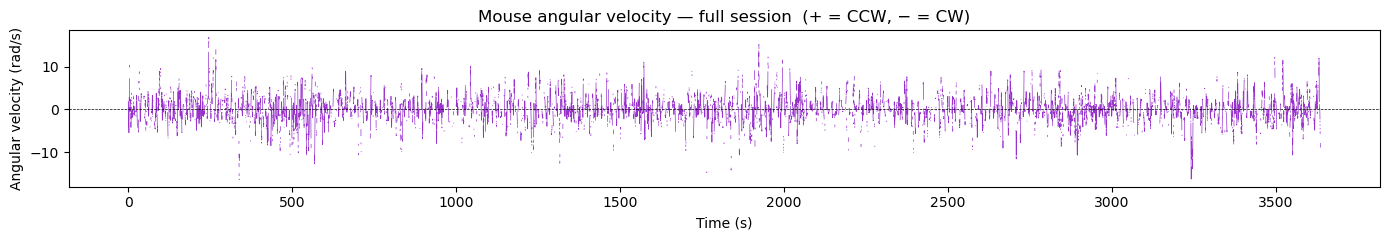

In [33]:
ANG_VEL_SMOOTH_SIGMA_S = 0.5   # seconds — Gaussian kernel width
MIN_DISP_PX            = 1.0   # pixels — ignore stationary/jitter frames

# Extract positions sorted by frame — same filtering as compute_path_speed's _frame_slice.
# Working directly on the sorted position sequence avoids the rounding artifact where
# np.round(midpoint_time * FPS) maps consecutive t_speed_abs samples to the SAME frame
# (zero displacement → NaN heading → no valid heading pairs).
_sub = sdf.loc[
    (sdf['frame_idx_global'] >= session_start_frame) &
    (sdf['frame_idx_global'] <= session_end_frame),
    ['frame_idx_global', 'headstage_x', 'headstage_y'],
].sort_values('frame_idx_global').copy()

_frames = _sub['frame_idx_global'].values.astype(float)
_x = pd.to_numeric(_sub['headstage_x'], errors='coerce').values.astype(float)
_y = pd.to_numeric(_sub['headstage_y'], errors='coerce').values.astype(float)

# Midpoint absolute times — same formula as compute_path_speed, matches t_speed_abs
_mid_t_abs = ((_frames[:-1] + _frames[1:]) / 2.0) / FPS

# Heading direction at each consecutive frame pair
_dx    = np.diff(_x)
_dy    = np.diff(_y)
_disp  = np.sqrt(_dx ** 2 + _dy ** 2)
_valid = ~(np.isnan(_disp) | (_disp < MIN_DISP_PX))
_heading = np.where(_valid, np.arctan2(_dy, _dx), np.nan)   # shape: N-1

# Angular velocity: dtheta = heading[i] - heading[i-1], wrapped to [-pi, pi]
_dtheta     = (_heading[1:] - _heading[:-1] + np.pi) % (2 * np.pi) - np.pi
_valid_pair = ~np.isnan(_heading[1:]) & ~np.isnan(_heading[:-1])
_dt_mid     = np.diff(_mid_t_abs)
_dt_safe    = np.where(_dt_mid > 0, _dt_mid, np.nan)

_ang_vel_raw = np.full(len(_mid_t_abs), np.nan)
_ang_vel_raw[1:] = np.where(_valid_pair, _dtheta / _dt_safe, np.nan)

# Gaussian smooth
_dt_sample = float(np.median(np.diff(_mid_t_abs)))
_tmp = np.where(np.isnan(_ang_vel_raw), 0.0, _ang_vel_raw)
_ang_vel_smooth = gaussian_filter1d(_tmp, sigma=ANG_VEL_SMOOTH_SIGMA_S / _dt_sample)
_ang_vel_smooth[np.isnan(_ang_vel_raw)] = np.nan

# Align to t_speed_abs (should be identical length; interpolate only if summary_df
# had duplicates processed differently by compute_path_speed)
if len(_mid_t_abs) == len(t_speed_abs):
    ang_vel_global = _ang_vel_smooth
else:
    print(f"  Length mismatch ({len(_mid_t_abs)} vs {len(t_speed_abs)}) — interpolating...")
    _ok = ~np.isnan(_ang_vel_smooth)
    from scipy.interpolate import interp1d
    ang_vel_global = (
        interp1d(_mid_t_abs[_ok], _ang_vel_smooth[_ok],
                 bounds_error=False, fill_value=np.nan)(t_speed_abs)
        if _ok.sum() >= 2 else np.full(len(t_speed_abs), np.nan)
    )

print(f"Angular velocity samples: {len(ang_vel_global)}  "
      f"(NaN: {np.isnan(ang_vel_global).sum()})")

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.plot(t_speed_abs, ang_vel_global, linewidth=0.5, color='darkorchid')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular velocity (rad/s)')
ax.set_title('Mouse angular velocity — full session  (+ = CCW, − = CW)')
plt.tight_layout()
plt.show()


## Compute correlations for all good + MUA units (angular velocity)

Pearson r between each unit's firing rate and `ang_vel_global`.
Reuses `rate_matrix` built in the population section above.

In [34]:
valid_ang_mask = ~np.isnan(ang_vel_global)

ang_corr_results = []
for i, row in all_units.iterrows():
    cid = int(row['cluster_id'])
    grp = row['group']

    if valid_ang_mask.sum() < MIN_VALID_SAMPLES:
        ang_corr_results.append({'cluster_id': cid, 'group': grp, 'r': np.nan, 'p': np.nan})
        continue

    r, p = pearsonr(ang_vel_global[valid_ang_mask], rate_matrix[valid_ang_mask, i])
    ang_corr_results.append({'cluster_id': cid, 'group': grp, 'r': r, 'p': p})

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(all_units)} units done…")

ang_corr_df = (pd.DataFrame(ang_corr_results)
               .sort_values('r', ascending=False)
               .reset_index(drop=True))
print(f"\nDone. {len(ang_corr_df)} units.")
ang_corr_df.head(20)


  10/171 units done…
  20/171 units done…
  30/171 units done…
  40/171 units done…
  50/171 units done…
  60/171 units done…
  70/171 units done…
  80/171 units done…
  90/171 units done…
  100/171 units done…
  110/171 units done…
  120/171 units done…
  130/171 units done…
  140/171 units done…
  150/171 units done…
  160/171 units done…
  170/171 units done…

Done. 171 units.


,cluster_id,group,r,p
0,444,mua,0.055243,3.076364e-46
1,21,mua,0.054170,1.590015e-44
2,201,mua,0.041785,3.633365e-27
3,107,mua,0.039001,7.123003e-24
4,798,mua,0.036198,8.721731e-21
5,534,mua,0.034524,4.757157e-19
6,543,good,0.034027,1.502539e-18
7,524,mua,0.032973,1.636054e-17
8,370,mua,0.027604,1.006286e-12
9,26,good,0.024699,1.783464e-10


## Angular velocity correlation distribution — choose threshold

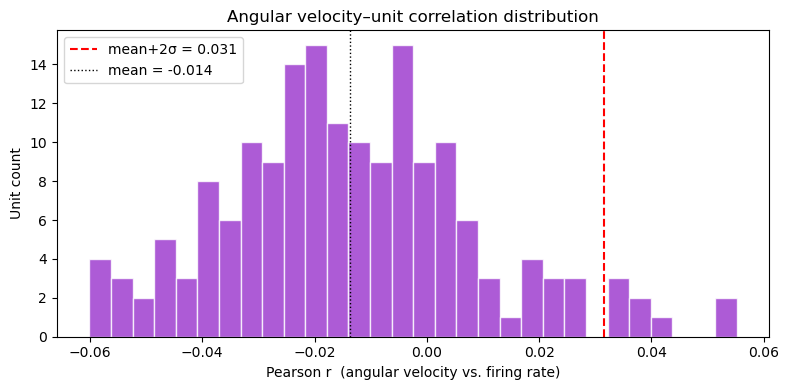

mean=-0.014  σ=0.023  mean+2σ=0.031
Units above threshold: 8  (good: 1, mua: 7)


In [35]:
ang_r_vals = ang_corr_df['r'].dropna()
ang_mu, ang_sigma = ang_r_vals.mean(), ang_r_vals.std()
ang_threshold_2sd = ang_mu + 2 * ang_sigma

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ang_r_vals, bins=30, color='darkorchid', edgecolor='white', alpha=0.8)
ax.axvline(ang_threshold_2sd, color='red',   linestyle='--', linewidth=1.5,
           label=f'mean+2σ = {ang_threshold_2sd:.3f}')
ax.axvline(ang_mu,            color='black', linestyle=':',  linewidth=1.0,
           label=f'mean = {ang_mu:.3f}')
ax.set_xlabel('Pearson r  (angular velocity vs. firing rate)')
ax.set_ylabel('Unit count')
ax.set_title('Angular velocity–unit correlation distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"mean={ang_mu:.3f}  σ={ang_sigma:.3f}  mean+2σ={ang_threshold_2sd:.3f}")
print(f"Units above threshold: {(ang_r_vals > ang_threshold_2sd).sum()}  "
      f"(good: {((ang_corr_df['r'] > ang_threshold_2sd) & (ang_corr_df['group'] == 'good')).sum()}, "
      f"mua: {((ang_corr_df['r'] > ang_threshold_2sd) & (ang_corr_df['group'] == 'mua')).sum()})")


In [36]:
ANG_CORR_THRESHOLD = ang_threshold_2sd   # ← edit manually after inspecting histogram

high_ang_corr = ang_corr_df[ang_corr_df['r'] > ANG_CORR_THRESHOLD].reset_index(drop=True)
print(f"Units above threshold ({ANG_CORR_THRESHOLD:.3f}): {len(high_ang_corr)}")
display(high_ang_corr)


Units above threshold (0.031): 8


,cluster_id,group,r,p
0,444,mua,0.055243,3.076364e-46
1,21,mua,0.054170,1.590015e-44
2,201,mua,0.041785,3.633365e-27
3,107,mua,0.039001,7.123003e-24
4,798,mua,0.036198,8.721731e-21
5,534,mua,0.034524,4.757157e-19
6,543,good,0.034027,1.502539e-18
7,524,mua,0.032973,1.636054e-17


## High angular-velocity-correlation units — random session window

Randomly chosen 60-second window showing angular velocity and firing rate overlaid
for each unit above threshold (purple = angular velocity, orange = firing rate).

Plotting 8 units, window 1518.6–1578.6 s


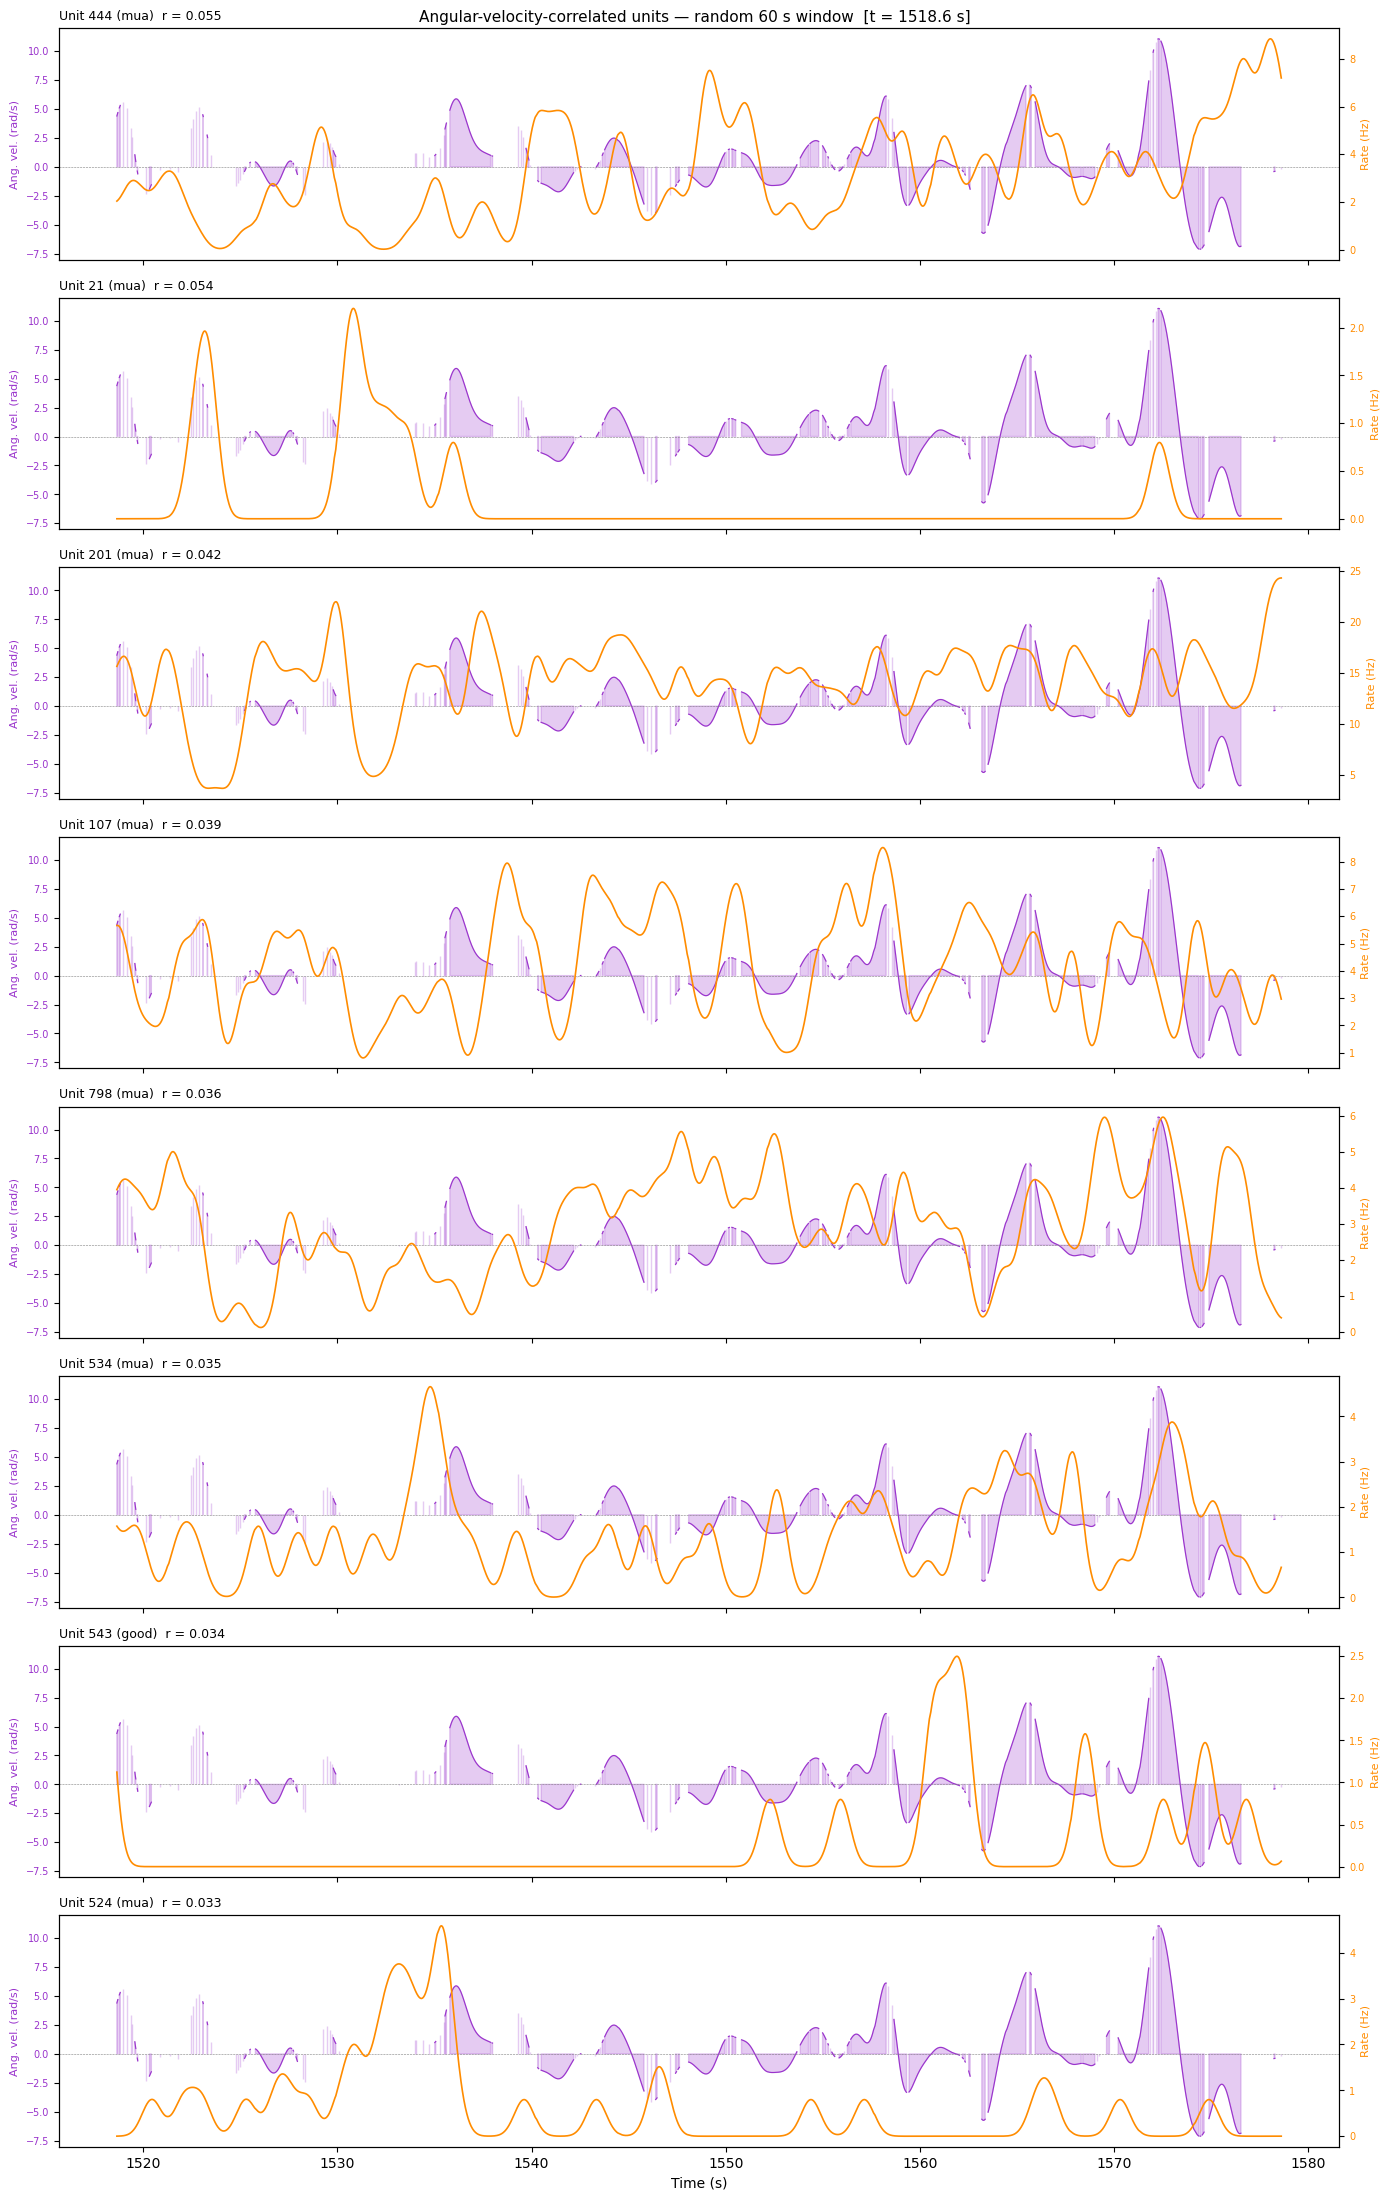

In [37]:
t_win_start_ang = t_speed_abs[0] + random.uniform(
    0, max(0, (t_speed_abs[-1] - t_speed_abs[0]) - WINDOW_S))
t_win_end_ang   = t_win_start_ang + WINDOW_S

win_mask_ang = (t_speed_abs >= t_win_start_ang) & (t_speed_abs <= t_win_end_ang)
t_win_ang    = t_speed_abs[win_mask_ang]
av_win       = ang_vel_global[win_mask_ang]

units_to_plot_ang = high_ang_corr.head(MAX_PANELS)
n_panels_ang      = len(units_to_plot_ang)
print(f"Plotting {n_panels_ang} units, window {t_win_start_ang:.1f}–{t_win_end_ang:.1f} s")

if n_panels_ang == 0:
    print("No units above threshold — lower ANG_CORR_THRESHOLD and re-run.")
else:
    fig, axes = plt.subplots(n_panels_ang, 1,
                             figsize=(14, 2.8 * n_panels_ang),
                             sharex=True)
    if n_panels_ang == 1:
        axes = [axes]

    for ax, (_, urow) in zip(axes, units_to_plot_ang.iterrows()):
        cid = int(urow['cluster_id'])
        spikes    = get_all_spikes_abs(cid)
        rate_full = compute_rate_on_axis(spikes, t_speed_abs)
        rate_win_ang = rate_full[win_mask_ang]

        ax2 = ax.twinx()
        ax.fill_between(t_win_ang, av_win, alpha=0.25, color='darkorchid')
        ax.plot(t_win_ang, av_win, color='darkorchid', linewidth=0.8)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax.set_ylabel('Ang. vel. (rad/s)', color='darkorchid', fontsize=8)
        ax.tick_params(axis='y', labelcolor='darkorchid', labelsize=7)

        ax2.plot(t_win_ang, rate_win_ang, color='darkorange', linewidth=1.2)
        ax2.set_ylabel('Rate (Hz)', color='darkorange', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=7)

        ax.set_title(
            f"Unit {cid} ({urow['group']})  r = {urow['r']:.3f}",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"Angular-velocity-correlated units — random {int(WINDOW_S)} s window  "
        f"[t = {t_win_start_ang:.1f} s]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


## Best-correlated time segments (angular velocity)

Same rolling-window approach as the speed analysis: a `ROLLING_WINDOW_S`-second window
slides across the session and the top `TOP_SEGMENTS` non-overlapping windows with the
highest local r are extracted and plotted.  `rolling_corr_ang` is defined here
(it reuses `win_n`, `step_n`, and `pick_top_segments` from the speed section above).

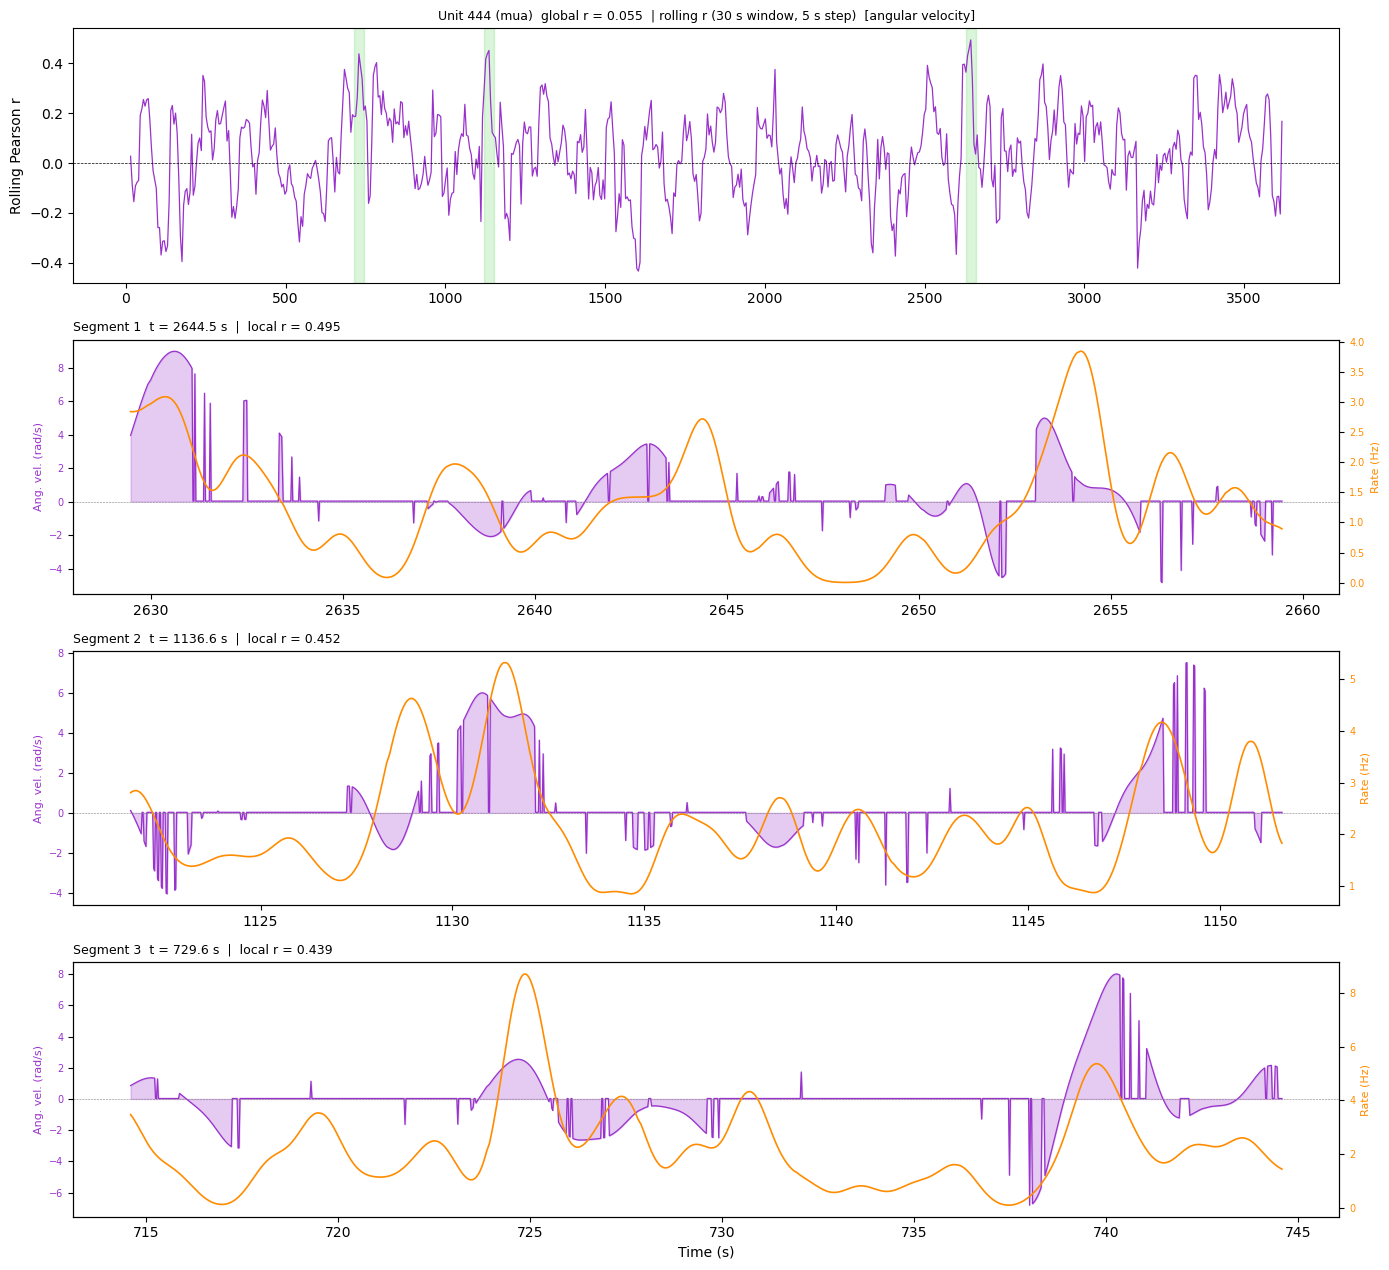

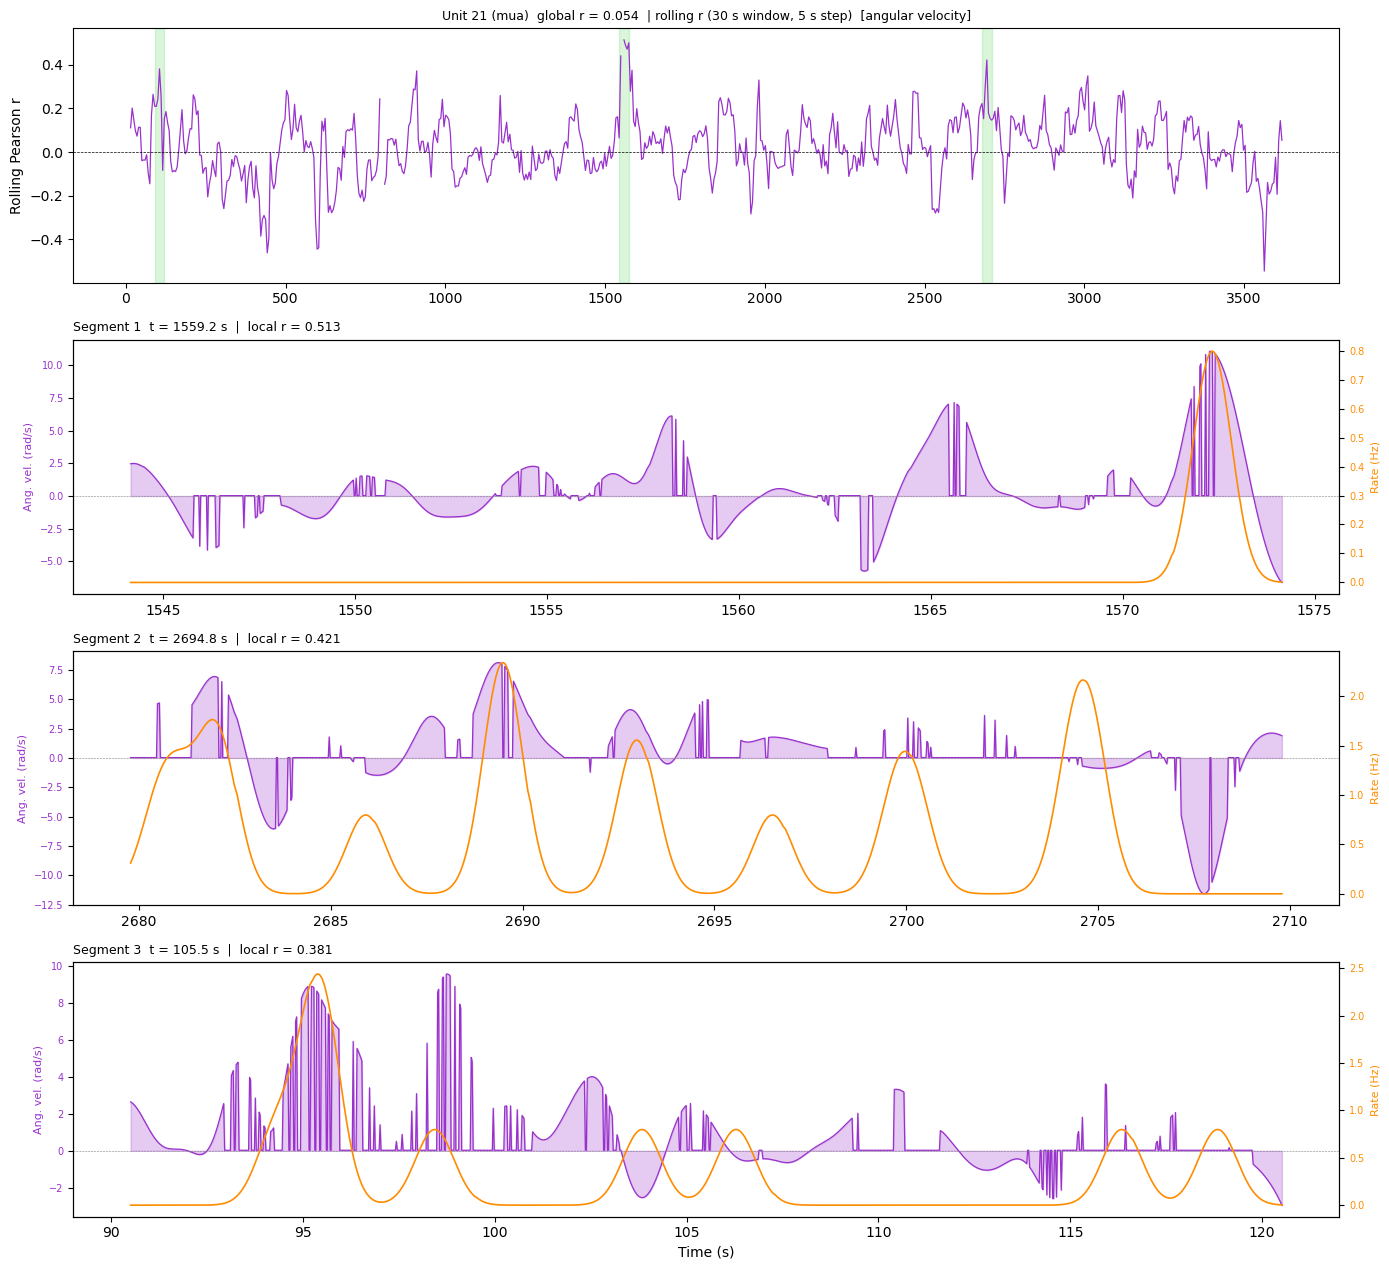

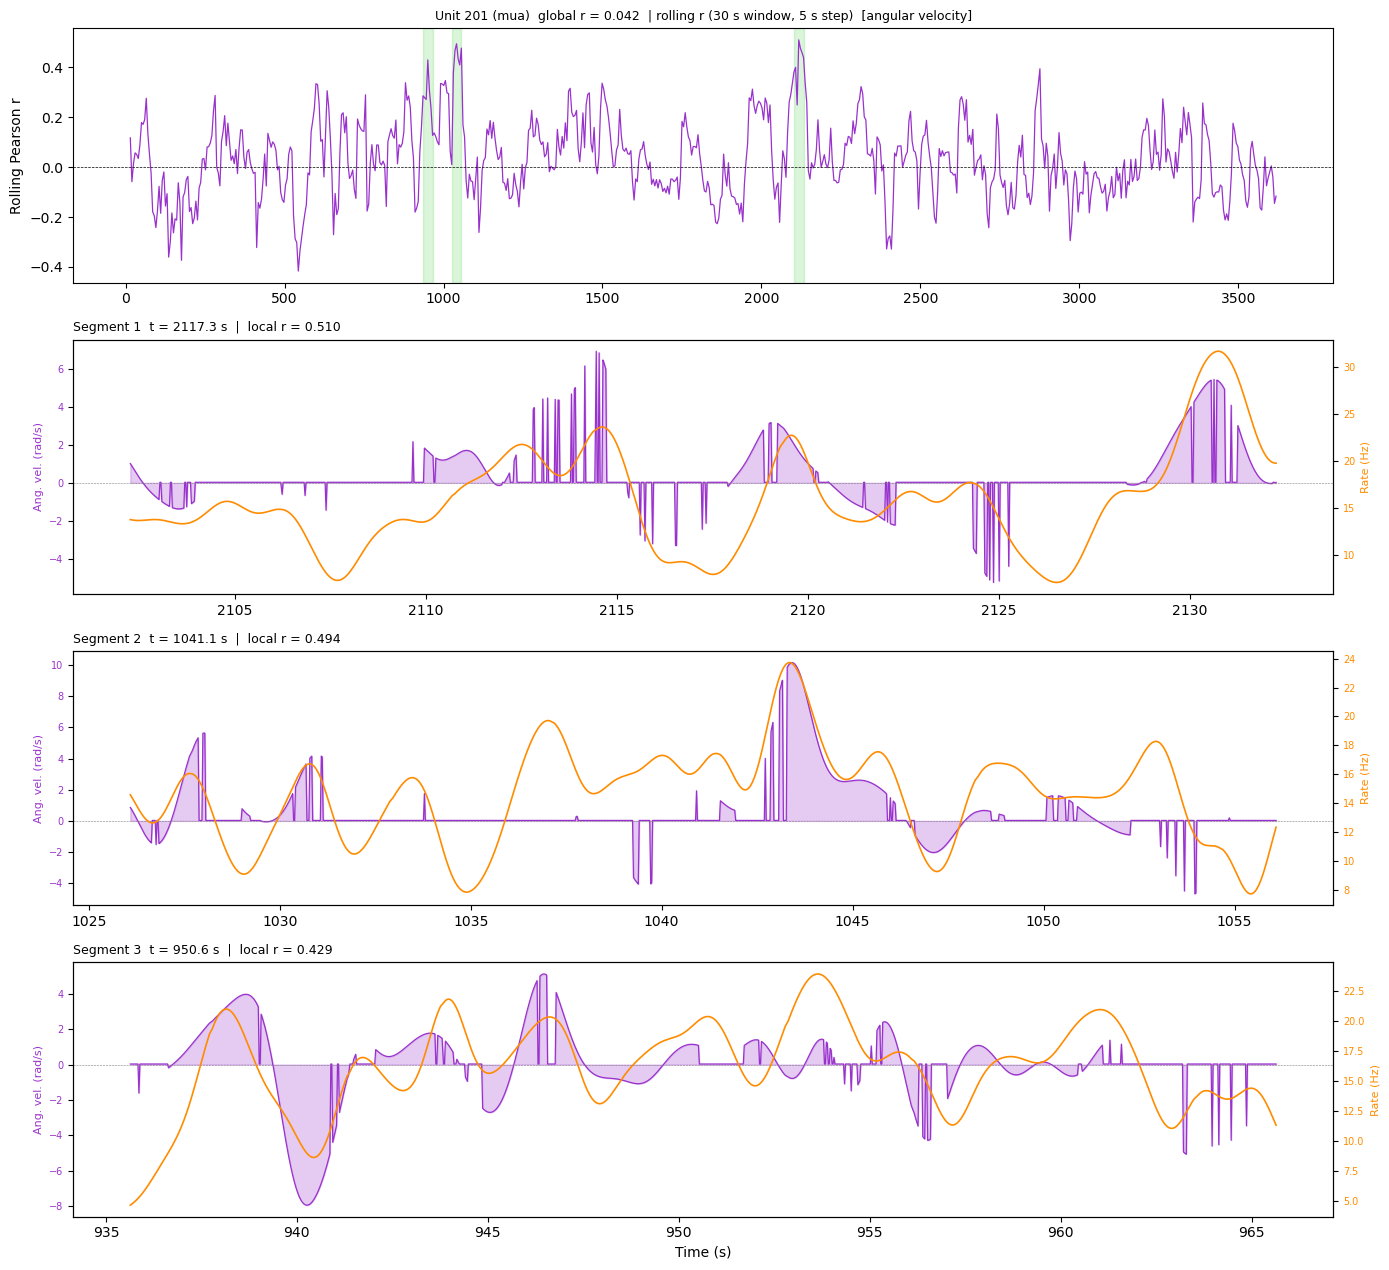

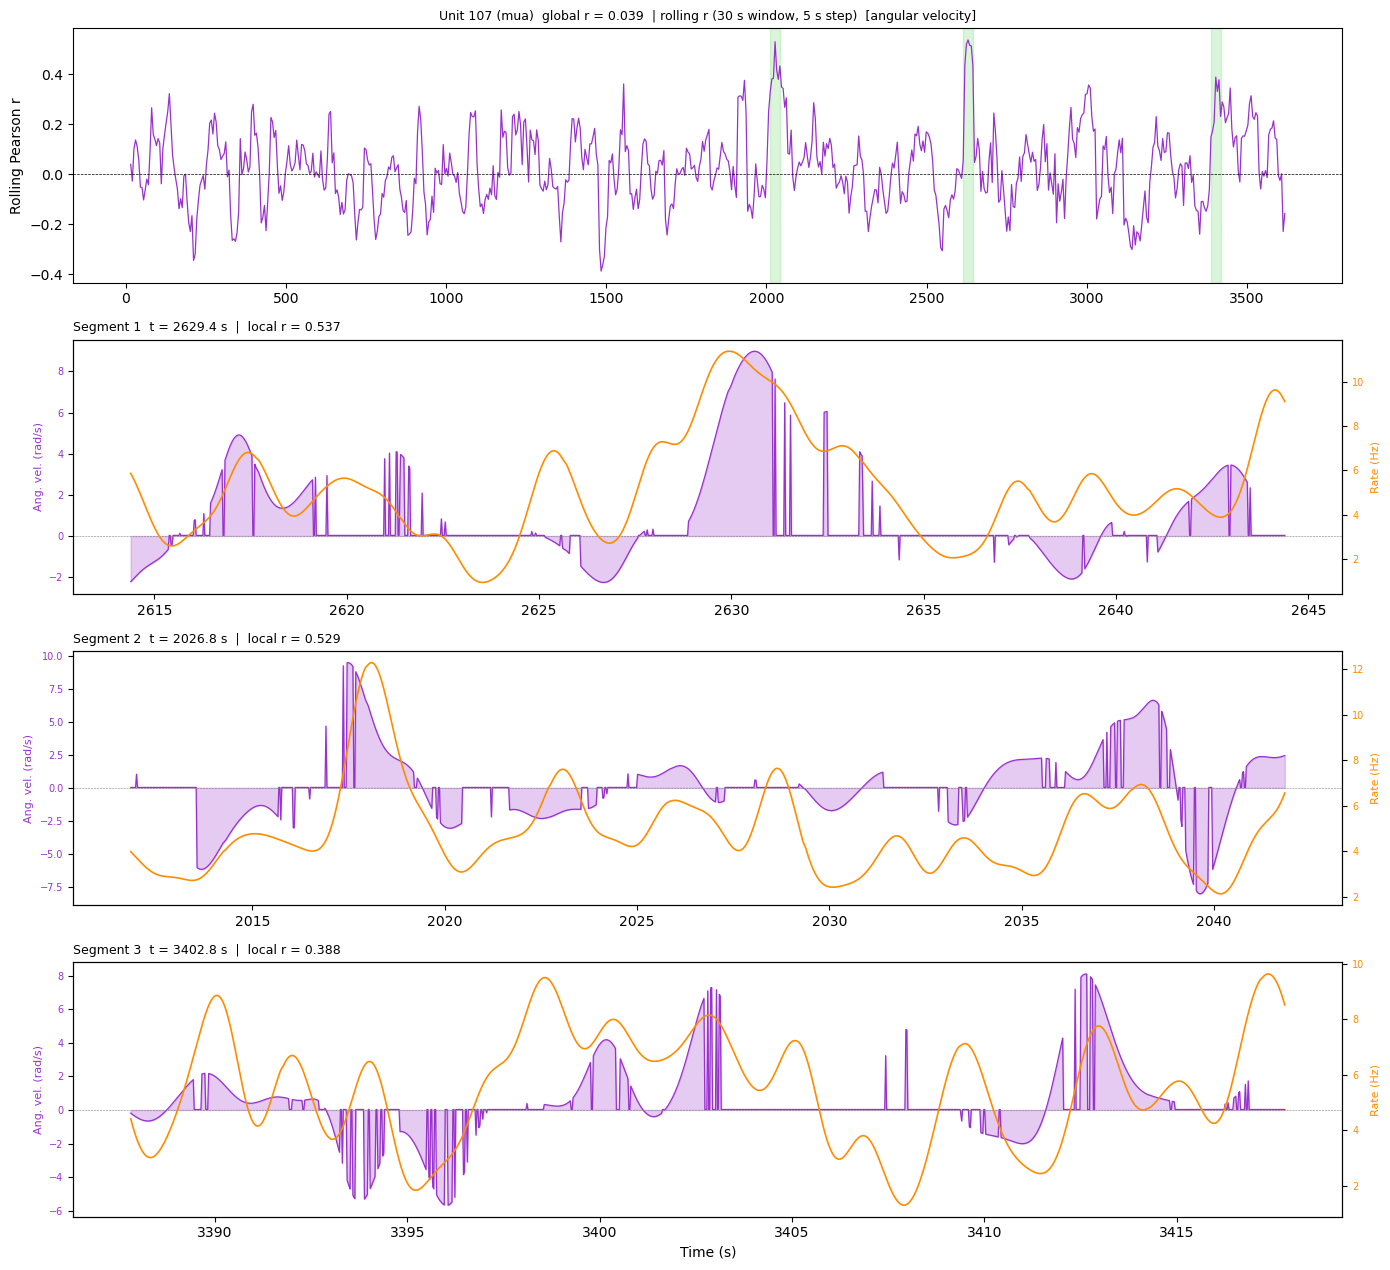

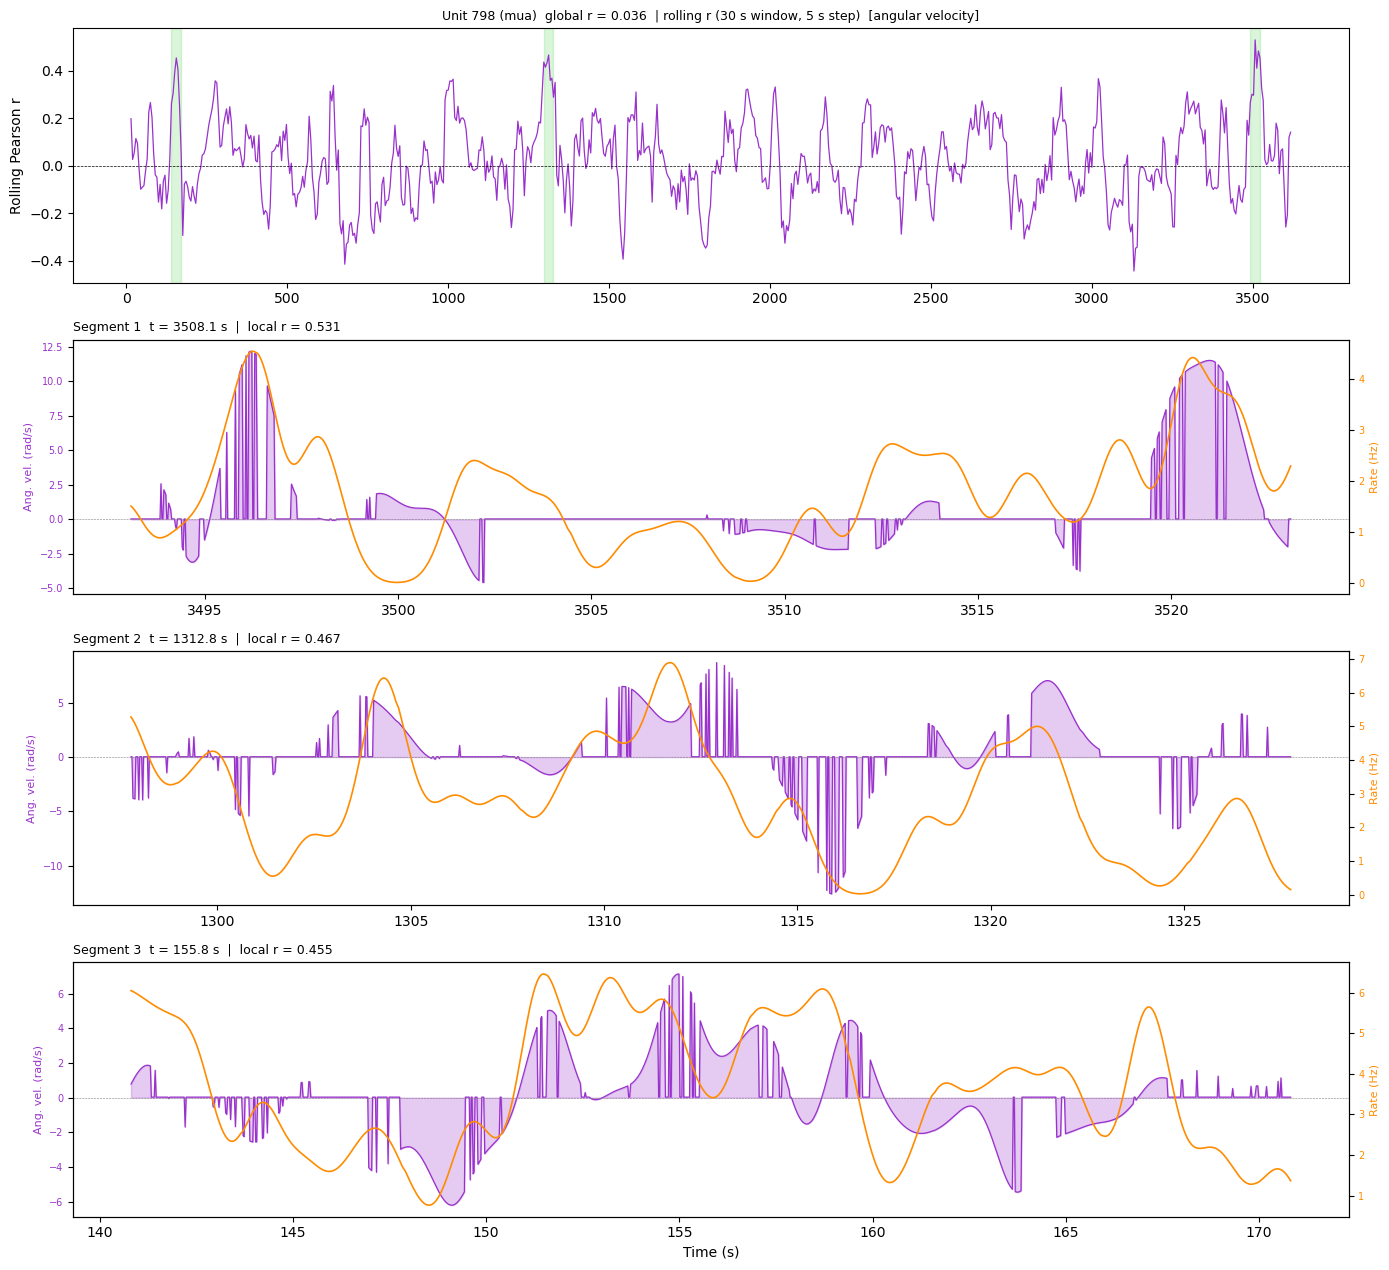

In [38]:
ang_vel_filled = np.where(
    np.isnan(ang_vel_global),
    float(np.nanmedian(ang_vel_global)),
    ang_vel_global,
)


def rolling_corr_ang(series):
    """Return (t_centers, r_values) sliding window, correlated with angular velocity."""
    r_vals, t_cens = [], []
    for i in range(0, len(t_speed_abs) - win_n, step_n):
        av_seg = ang_vel_filled[i:i + win_n]
        s_seg  = series[i:i + win_n]
        if np.std(av_seg) > 1e-9 and np.std(s_seg) > 1e-9:
            r_vals.append(np.corrcoef(av_seg, s_seg)[0, 1])
        else:
            r_vals.append(np.nan)
        t_cens.append(t_speed_abs[i + win_n // 2])
    return np.array(t_cens), np.array(r_vals)


units_ang_detail = high_ang_corr.head(MAX_UNITS_DETAIL)

for _, urow in units_ang_detail.iterrows():
    cid      = int(urow['cluster_id'])
    grp      = urow['group']
    r_global = urow['r']

    spikes    = get_all_spikes_abs(cid)
    rate_full = compute_rate_on_axis(spikes, t_speed_abs)

    t_cens_a, r_roll_a = rolling_corr_ang(rate_full)
    seg_centers_a      = pick_top_segments(t_cens_a, r_roll_a)

    n_segs_a = len(seg_centers_a)
    fig, axes = plt.subplots(1 + n_segs_a, 1,
                             figsize=(14, 3.2 * (1 + n_segs_a)))
    if 1 + n_segs_a == 1:
        axes = [axes]

    ax0 = axes[0]
    ax0.plot(t_cens_a, r_roll_a, color='darkorchid', linewidth=0.9)
    ax0.axhline(0, color='black', linewidth=0.5, linestyle='--')
    for tc in seg_centers_a:
        ax0.axvspan(tc - ROLLING_WINDOW_S / 2, tc + ROLLING_WINDOW_S / 2,
                    alpha=0.18, color='limegreen')
    ax0.set_ylabel('Rolling Pearson r')
    ax0.set_title(
        f"Unit {cid} ({grp})  global r = {r_global:.3f}  "
        f"| rolling r ({int(ROLLING_WINDOW_S)} s window, {int(ROLLING_STEP_S)} s step)  "
        f"[angular velocity]",
        fontsize=9
    )

    for k, tc in enumerate(seg_centers_a):
        ax = axes[k + 1]
        t0 = tc - ROLLING_WINDOW_S / 2
        t1 = tc + ROLLING_WINDOW_S / 2
        seg_mask = (t_speed_abs >= t0) & (t_speed_abs <= t1)
        t_seg   = t_speed_abs[seg_mask]
        av_seg  = ang_vel_filled[seg_mask]
        rt_seg  = rate_full[seg_mask]

        closest = int(np.argmin(np.abs(t_cens_a - tc)))
        r_local = r_roll_a[closest]

        ax2 = ax.twinx()
        ax.fill_between(t_seg, av_seg, alpha=0.25, color='darkorchid')
        ax.plot(t_seg, av_seg, color='darkorchid', linewidth=0.9)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax.set_ylabel('Ang. vel. (rad/s)', color='darkorchid', fontsize=8)
        ax.tick_params(axis='y', labelcolor='darkorchid', labelsize=7)

        ax2.plot(t_seg, rt_seg, color='darkorange', linewidth=1.2)
        ax2.set_ylabel('Rate (Hz)', color='darkorange', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=7)

        ax.set_title(
            f"Segment {k + 1}  t = {tc:.1f} s  |  local r = {r_local:.3f}",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()


## Population-level analysis: PC scores vs angular velocity

Reuse the PCA decomposition already computed for speed.  
Pearson r is computed between each PC score trajectory and `ang_vel_global` over all
valid (non-NaN) frames.  A bar chart mirrors the speed–PC chart above so you can
compare which PCs track translational vs rotational motion.

 pc         r    abs_r            p  var_exp
 15 -0.059802 0.059802 6.815889e-54 0.008302
 16 -0.056648 0.056648 1.557037e-48 0.007463
  4 -0.050140 0.050140 2.173591e-38 0.026631
  8 -0.042122 0.042122 1.402818e-27 0.014114
 13  0.038156 0.038156 6.419360e-23 0.009356
  1 -0.033956 0.033956 1.769508e-18 0.223072
 18 -0.032029 0.032029 1.307336e-16 0.006632
 10 -0.031952 0.031952 1.543647e-16 0.011935
  5 -0.025455 0.025455 4.885000e-11 0.023757
 20  0.019679 0.019679 3.730041e-07 0.006054
  9  0.019112 0.019112 7.984367e-07 0.012447
  6  0.017657 0.017657 5.116585e-06 0.018878
 11  0.016712 0.016712 1.589495e-05 0.010774
 17  0.015223 0.015223 8.452401e-05 0.007285
  7  0.012253 0.012253 1.555003e-03 0.016456
  3 -0.010816 0.010816 5.218908e-03 0.086359
 12 -0.005375 0.005375 1.651268e-01 0.009700
  2  0.003050 0.003050 4.309700e-01 0.118701
 14  0.003014 0.003014 4.363551e-01 0.008501
 19  0.002277 0.002277 5.565691e-01 0.006234


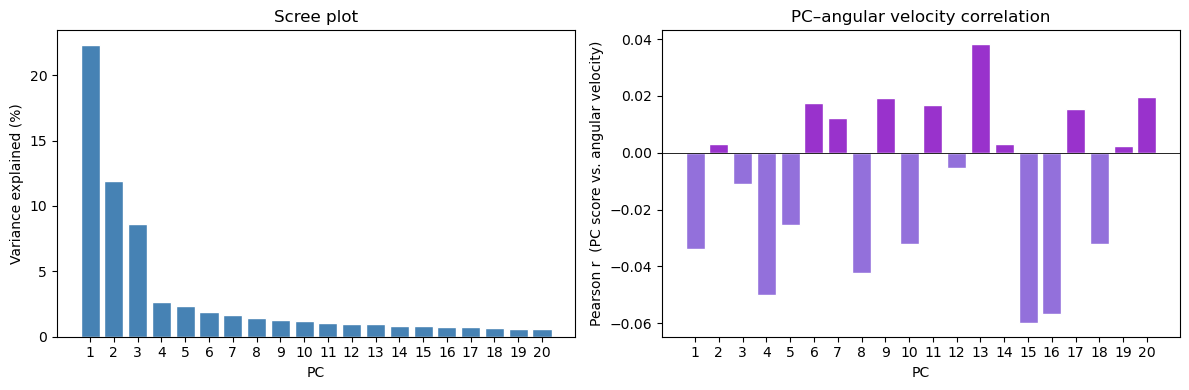

In [39]:
valid_ang = ~np.isnan(ang_vel_global)

pc_ang_corr = []
for k in range(N_COMPONENTS):
    r, p = pearsonr(ang_vel_global[valid_ang], pc_scores[valid_ang, k])
    pc_ang_corr.append({'pc': k + 1, 'r': r, 'abs_r': abs(r), 'p': p,
                        'var_exp': var_exp[k]})

pc_ang_corr_df = pd.DataFrame(pc_ang_corr)
print(pc_ang_corr_df.sort_values('abs_r', ascending=False).to_string(index=False))

# Overview: scree (same as before) + r bar chart per PC
fig, (ax_var, ax_r) = plt.subplots(1, 2, figsize=(12, 4))

pcs_a = pc_ang_corr_df['pc'].values

ax_var.bar(pcs_a, var_exp * 100, color='steelblue', edgecolor='white')
ax_var.set_xlabel('PC')
ax_var.set_ylabel('Variance explained (%)')
ax_var.set_title('Scree plot')
ax_var.set_xticks(pcs_a)

colors_ang = ['darkorchid' if r > 0 else 'mediumpurple' for r in pc_ang_corr_df['r']]
ax_r.bar(pcs_a, pc_ang_corr_df['r'].values, color=colors_ang, edgecolor='white')
ax_r.axhline(0, color='black', linewidth=0.6)
ax_r.set_xlabel('PC')
ax_r.set_ylabel('Pearson r  (PC score vs. angular velocity)')
ax_r.set_title('PC–angular velocity correlation')
ax_r.set_xticks(pcs_a)

plt.tight_layout()
plt.show()


In [40]:
PC_ANG_CORR_THRESHOLD = 0.1   # |r| threshold — adjust after seeing bar chart above
MAX_PC_ANG_DETAIL     = 5

top_pcs_ang = (pc_ang_corr_df[pc_ang_corr_df['abs_r'] > PC_ANG_CORR_THRESHOLD]
               .sort_values('abs_r', ascending=False)
               .head(MAX_PC_ANG_DETAIL))

print(f"PCs with |r| > {PC_ANG_CORR_THRESHOLD}: {len(top_pcs_ang)}")
display(top_pcs_ang)

# --- random window overview ---
t_pc_ang_start = t_speed_abs[0] + random.uniform(
    0, max(0, (t_speed_abs[-1] - t_speed_abs[0]) - WINDOW_S_PC))
t_pc_ang_end   = t_pc_ang_start + WINDOW_S_PC
win_mask_pcang = (t_speed_abs >= t_pc_ang_start) & (t_speed_abs <= t_pc_ang_end)
t_win_pcang    = t_speed_abs[win_mask_pcang]
av_win_pcang   = ang_vel_global[win_mask_pcang]

n_pca_panels = len(top_pcs_ang)
if n_pca_panels == 0:
    print("No PCs above threshold — lower PC_ANG_CORR_THRESHOLD and re-run.")
else:
    fig, axes = plt.subplots(n_pca_panels, 1,
                             figsize=(14, 2.8 * n_pca_panels),
                             sharex=True)
    if n_pca_panels == 1:
        axes = [axes]

    for ax, (_, prow) in zip(axes, top_pcs_ang.iterrows()):
        k         = int(prow['pc']) - 1
        r_pc      = prow['r']
        score_win = pc_scores[win_mask_pcang, k]

        ax2 = ax.twinx()
        ax.fill_between(t_win_pcang, av_win_pcang, alpha=0.25, color='darkorchid')
        ax.plot(t_win_pcang, av_win_pcang, color='darkorchid', linewidth=0.8)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax.set_ylabel('Ang. vel. (rad/s)', color='darkorchid', fontsize=8)
        ax.tick_params(axis='y', labelcolor='darkorchid', labelsize=7)

        ax2.plot(t_win_pcang, score_win, color='darkgreen', linewidth=1.2)
        ax2.set_ylabel('PC score (a.u.)', color='darkgreen', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=7)

        ax.set_title(
            f"PC{k + 1}  r = {r_pc:.3f}  |  var. exp. = {prow['var_exp'] * 100:.1f}%",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"Top angular-velocity-correlated PCs — random {int(WINDOW_S_PC)} s window  "
        f"[t = {t_pc_ang_start:.1f} s]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    # --- rolling correlation + best segments for each top PC ---
    for _, prow in top_pcs_ang.iterrows():
        k        = int(prow['pc']) - 1
        r_global = prow['r']
        score    = pc_scores[:, k]

        t_cens_pa, r_roll_pa = rolling_corr_ang(score)
        seg_centers_pa       = pick_top_segments(t_cens_pa, r_roll_pa)

        n_segs_pa = len(seg_centers_pa)
        fig, axes = plt.subplots(1 + n_segs_pa, 1,
                                 figsize=(14, 3.2 * (1 + n_segs_pa)))
        if 1 + n_segs_pa == 1:
            axes = [axes]

        ax0 = axes[0]
        ax0.plot(t_cens_pa, r_roll_pa, color='darkorchid', linewidth=0.9)
        ax0.axhline(0, color='black', linewidth=0.5, linestyle='--')
        for tc in seg_centers_pa:
            ax0.axvspan(tc - ROLLING_WINDOW_S / 2, tc + ROLLING_WINDOW_S / 2,
                        alpha=0.18, color='limegreen')
        ax0.set_ylabel('Rolling Pearson r')
        ax0.set_title(
            f"PC{k + 1}  global r = {r_global:.3f}  var. exp. = {prow['var_exp'] * 100:.1f}%  "
            f"| rolling r ({int(ROLLING_WINDOW_S)} s window)  [angular velocity]",
            fontsize=9
        )

        for j, tc in enumerate(seg_centers_pa):
            ax  = axes[j + 1]
            t0  = tc - ROLLING_WINDOW_S / 2
            t1  = tc + ROLLING_WINDOW_S / 2
            seg_mask = (t_speed_abs >= t0) & (t_speed_abs <= t1)
            t_seg    = t_speed_abs[seg_mask]
            av_seg   = ang_vel_filled[seg_mask]
            sc_seg   = score[seg_mask]

            closest = int(np.argmin(np.abs(t_cens_pa - tc)))
            r_local = r_roll_pa[closest]

            ax2 = ax.twinx()
            ax.fill_between(t_seg, av_seg, alpha=0.25, color='darkorchid')
            ax.plot(t_seg, av_seg, color='darkorchid', linewidth=0.9)
            ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
            ax.set_ylabel('Ang. vel. (rad/s)', color='darkorchid', fontsize=8)
            ax.tick_params(axis='y', labelcolor='darkorchid', labelsize=7)

            ax2.plot(t_seg, sc_seg, color='darkgreen', linewidth=1.2)
            ax2.set_ylabel('PC score (a.u.)', color='darkgreen', fontsize=8)
            ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=7)

            ax.set_title(
                f"Segment {j + 1}  t = {tc:.1f} s  |  local r = {r_local:.3f}",
                fontsize=9, loc='left'
            )

        axes[-1].set_xlabel('Time (s)')
        plt.tight_layout()
        plt.show()


PCs with |r| > 0.1: 0


,pc,r,abs_r,p,var_exp


No PCs above threshold — lower PC_ANG_CORR_THRESHOLD and re-run.


## Angular velocity profile centred on turn location

Mirrors the speed-by-distance analysis: mean angular velocity as a function of
signed Euclidean distance from the turn point (negative = approaching, positive =
leaving).  Both midpoint and refined timing are shown, and a per-level breakdown
follows.  High |angular velocity| near distance 0 would confirm that the spatial
peak of rotational motion aligns with the detected turn location.

Computing angular-velocity-by-distance profiles…
Done.


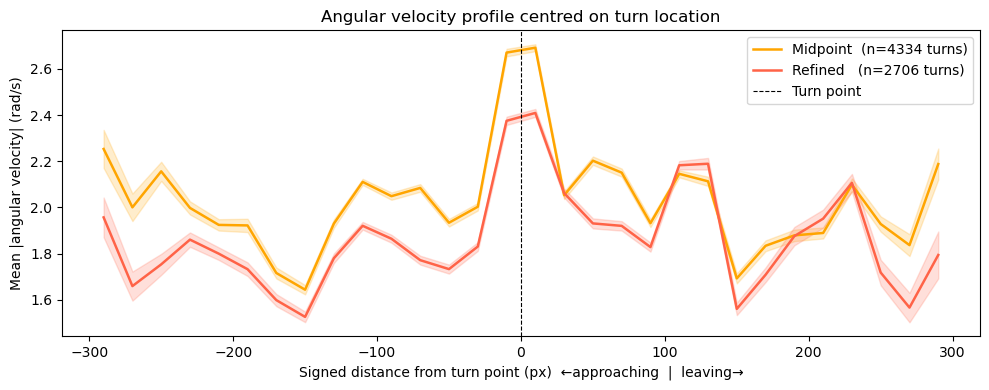

In [41]:
# Reuse DIST_BIN_PX, MAX_DIST_PX, DIST_WIN_S, dist_bins, bin_centers, frame_to_x/y
# from the speed-by-distance section above (cell 89bcaf44).

def _ang_vel_by_distance(turn_t_col, turn_frame_col):
    """Mean angular velocity ± SEM vs signed distance from turn point.

    Sign convention matches _speed_by_distance: negative before the turn, positive after.
    Angular velocity is absolute |ω| so that CW and CCW turns both show a peak at 0.
    """
    bin_avs = [[] for _ in range(len(dist_bins) - 1)]
    for t_turn, f_turn in zip(turn_t_col, turn_frame_col):
        f_turn = int(round(f_turn))
        tx = frame_to_x.get(f_turn)
        ty = frame_to_y.get(f_turn)
        if tx is None or ty is None:
            continue
        win_idx = np.where(np.abs(t_speed_abs - t_turn) <= DIST_WIN_S)[0]
        px   = pos_x[win_idx]
        py   = pos_y[win_idx]
        av   = ang_vel_global[win_idx]
        t_w  = t_speed_abs[win_idx]
        dists  = np.sqrt((px - tx) ** 2 + (py - ty) ** 2)
        signed = np.where(t_w < t_turn, -dists, dists)
        valid  = ~(np.isnan(signed) | np.isnan(av))
        for sd, a in zip(signed[valid], np.abs(av[valid])):
            b = np.searchsorted(dist_bins, sd, side='right') - 1
            if 0 <= b < len(bin_avs):
                bin_avs[b].append(a)
    means = [np.nanmean(b) if b else np.nan for b in bin_avs]
    sems  = [np.nanstd(b) / np.sqrt(len(b)) if len(b) > 1 else np.nan for b in bin_avs]
    return np.array(means), np.array(sems)


print("Computing angular-velocity-by-distance profiles…")
av_mean_mid, av_sem_mid = _ang_vel_by_distance(
    turn_df['t_midpoint_abs'], turn_df['midpoint_frame'])
av_mean_ref, av_sem_ref = _ang_vel_by_distance(
    turn_refined['t_refined_abs'], turn_refined['refined_turn_frame_global'])
print("Done.")

fig, ax = plt.subplots(figsize=(10, 4))
for means, sems, label, color in [
    (av_mean_mid, av_sem_mid, f'Midpoint  (n={len(turn_df)} turns)',      'orange'),
    (av_mean_ref, av_sem_ref, f'Refined   (n={len(turn_refined)} turns)', 'tomato'),
]:
    ax.plot(bin_centers, means, color=color, linewidth=1.8, label=label)
    ax.fill_between(bin_centers, means - sems, means + sems, color=color, alpha=0.2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', label='Turn point')
ax.set_xlabel('Signed distance from turn point (px)  ←approaching  |  leaving→')
ax.set_ylabel('Mean |angular velocity| (rad/s)')
ax.set_title('Angular velocity profile centred on turn location')
ax.legend()
plt.tight_layout()
plt.show()


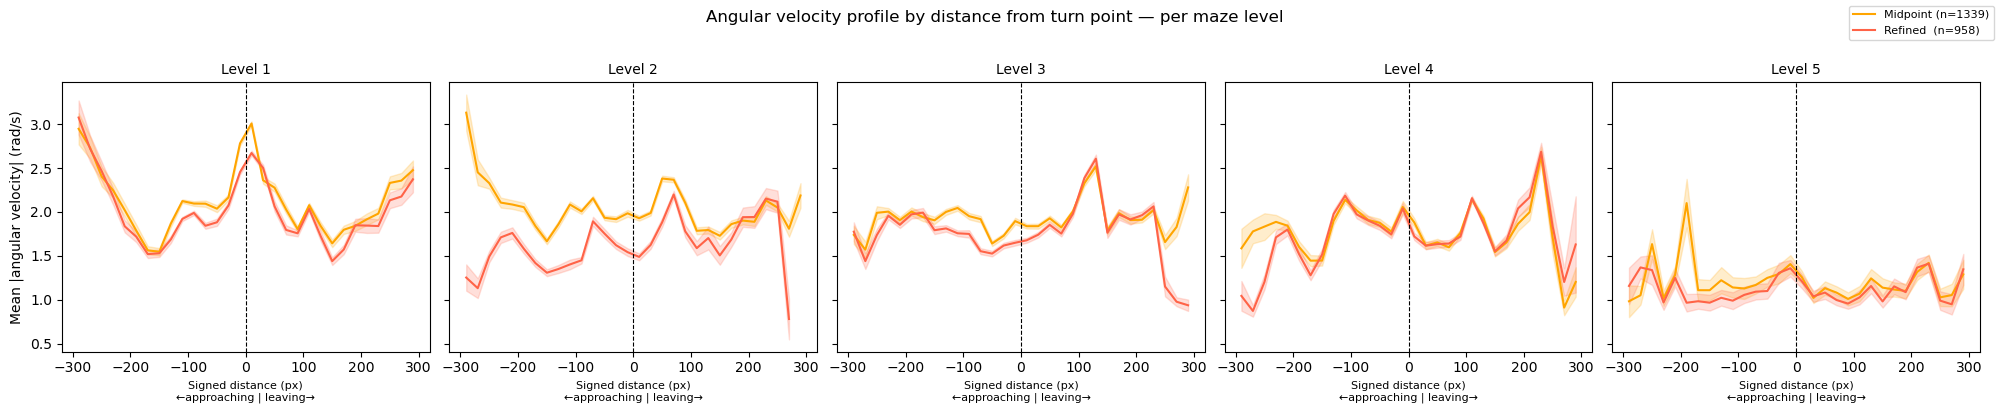

In [42]:
levels_ang = sorted(turn_df['curr_node_level'].dropna().unique())
n_levels_ang = len(levels_ang)

fig, axes = plt.subplots(1, n_levels_ang, figsize=(4 * n_levels_ang, 4), sharey=True)
if n_levels_ang == 1:
    axes = [axes]

for ax, lvl in zip(axes, levels_ang):
    td_lvl = turn_df[turn_df['curr_node_level'] == lvl]
    tr_lvl = turn_refined[turn_refined['curr_node_level'] == lvl]

    for t_col, f_col, df_lvl, label, color in [
        ('t_midpoint_abs', 'midpoint_frame',            td_lvl, f'Midpoint (n={len(td_lvl)})', 'orange'),
        ('t_refined_abs',  'refined_turn_frame_global', tr_lvl, f'Refined  (n={len(tr_lvl)})', 'tomato'),
    ]:
        if df_lvl.empty:
            continue
        means, sems = _ang_vel_by_distance(df_lvl[t_col], df_lvl[f_col])
        ax.plot(bin_centers, means, color=color, linewidth=1.5, label=label)
        ax.fill_between(bin_centers, means - sems, means + sems, color=color, alpha=0.2)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Level {int(lvl)}', fontsize=10)
    ax.set_xlabel('Signed distance (px)\n←approaching | leaving→', fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel('Mean |angular velocity| (rad/s)')

handles, labels = axes[0].get_legend_handles_labels()
if not handles:
    handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=8)
fig.suptitle(
    'Angular velocity profile by distance from turn point — per maze level', y=1.02)
plt.tight_layout()
plt.show()
